# Домашняя работа №1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import time
from datetime import datetime
from torchvision.datasets import CIFAR100
from torchvision import transforms
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

now = datetime.now()
warnings.filterwarnings('ignore')
%matplotlib inline
date_time = now.strftime("%Y-%m-%d %H:%M:%S")
np.random.seed(42)


In [ ]:
Name = "Маскалева Полина Юрьевна"
Group = "ЗФИбд-01-24"
StudentNumber = "1132243257"
print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


Name: Маскалева Полина Юрьевна, Group: ЗФИбд-01-24, StudentNumber: 1132243257, DateTime: 2026-05-08 10:35:48


#### Домашнее задание № 1
- Реализовать класс для классификации
- Реализовать класс для регресии


In [ ]:
class KnnClassifier:
    # k-Nearest Neighbors классификатор: на predict для каждого тестового
    # объекта находит k ближайших соседей в обучающей выборке и голосует
    # мажоритарно по их меткам.
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y)
        self._train_norm = (self.X_train ** 2).sum(axis=1)
        return self

    def _knn_indices(self, X, batch=512):
        # Возвращает индексы k ближайших соседей для каждого объекта в X.
        # Используется тождество ||x - y||² = ||x||² + ||y||² - 2·x·y,
        # которое позволяет считать расстояния без выделения большого тензора.
        X = np.asarray(X, dtype=np.float64)
        x_norm = (X ** 2).sum(axis=1)
        k = self.k
        out = np.empty((len(X), k), dtype=np.int64)
        for s in range(0, len(X), batch):
            e = min(s + batch, len(X))
            D2 = x_norm[s:e, None] + self._train_norm[None, :] - 2.0 * (X[s:e] @ self.X_train.T)
            np.maximum(D2, 0.0, out=D2)  # численное обнуление маленьких отрицательных
            # argpartition даёт O(n) вместо O(n*log(n)) — нам не нужен порядок внутри top-k
            out[s:e] = np.argpartition(D2, kth=k - 1, axis=1)[:, :k]
        return out

    def predict(self, X):
        idx = self._knn_indices(X)
        labels = self.y_train[idx]
        preds = np.empty(len(idx), dtype=self.y_train.dtype)
        for i in range(len(idx)):
            vals, counts = np.unique(labels[i], return_counts=True)
            preds[i] = vals[counts.argmax()]
        return preds


In [ ]:
model = KnnClassifier(k=3)
X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
X_test = np.array([[5, 5], [2, 2]])
model.fit(X_train, y_train)
assert all(model.predict(X_test) == [1, 0])

print(f"Name: {Name}, Group: {Group}, StudentNumber: {StudentNumber}, DateTime: {date_time}")


Name: Маскалева Полина Юрьевна, Group: ЗФИбд-01-24, StudentNumber: 1132243257, DateTime: 2026-05-08 10:35:48


In [ ]:
class KnnRegressor:
    # k-Nearest Neighbors регрессор: на predict для каждого тестового объекта
    # находит k ближайших соседей и возвращает среднее их целевых значений.
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y, dtype=np.float64)
        self._train_norm = (self.X_train ** 2).sum(axis=1)
        return self

    def _knn_indices(self, X, batch=512):
        X = np.asarray(X, dtype=np.float64)
        x_norm = (X ** 2).sum(axis=1)
        k = self.k
        out = np.empty((len(X), k), dtype=np.int64)
        for s in range(0, len(X), batch):
            e = min(s + batch, len(X))
            D2 = x_norm[s:e, None] + self._train_norm[None, :] - 2.0 * (X[s:e] @ self.X_train.T)
            np.maximum(D2, 0.0, out=D2)
            out[s:e] = np.argpartition(D2, kth=k - 1, axis=1)[:, :k]
        return out

    def predict(self, X):
        idx = self._knn_indices(X)
        return self.y_train[idx].mean(axis=1)

y_reg = np.array([1., 2., 3., 4., 5., 6., 7., 8., 9., 10.])
mr = KnnRegressor(k=3).fit(X_train, y_reg)
# Для [5, 5] три ближайших соседа: [4,4],[5,5],[6,6] → среднее(4,5,6)=5
# Для [2, 2] три ближайших соседа: [1,1],[2,2],[3,3] → среднее(1,2,3)=2
assert np.allclose(mr.predict(X_test), [5., 2.])
print("KnnRegressor: тест пройден, predict =", mr.predict(X_test))


KnnRegressor: тест пройден, predict = [5. 2.]


### Выводы по Домашнему заданию №1

**Что реализовано.** Два класса: `KnnClassifier` (мажоритарное голосование по `k` ближайшим соседям) и `KnnRegressor` (среднее целевых значений `k` ближайших соседей). Оба класса проходят проверочные тесты из шаблона:
- `KnnClassifier(k=3)` на тестовых точках `[5,5]` и `[2,2]` возвращает `[1, 0]` ✓
- `KnnRegressor(k=3)` на тех же точках возвращает `[5., 2.]` ✓

**Технические решения для эффективности.**

1. **Расстояние через тождество.** Вместо прямой формулы $\|x-y\|^2$ используется $\|x-y\|^2 = \|x\|^2 + \|y\|^2 - 2\,x\!\cdot\!y$. Это позволяет считать расстояния матричным умножением `X @ X_train.T` вместо broadcasting'а трёхмерного тензора, что экономит память в `D` (размерности признаков) раз.

2. **`np.argpartition` вместо `np.argsort`.** Для поиска `k` ближайших соседей не нужен полный порядок — нужен только сам набор top-k. `argpartition` даёт сложность $O(n)$ вместо $O(n \log n)$ у `argsort`. На большой обучающей выборке (например, CIFAR с 20 000 объектов) это даёт ускорение в несколько раз.

3. **Батчевание в `predict`.** Когда тестовая выборка большая, мы обрабатываем её порциями по 512 объектов, чтобы не выделять матрицу расстояний размером $(N_\text{test} \times N_\text{train})$ целиком.

**Сложность алгоритма.** $O(N_\text{test} \cdot N_\text{train} \cdot D)$ — это фундаментальная цена «ленивого» обучения KNN: модель не строит явное правило, поэтому всю работу приходится делать на этапе предсказания.


#### Домашнее задание № 2

В рамках данного задания необходимо реализовать  метода классификации изображений — k-nearest neighbors  на датасете CIFAR-100.

Цель: исследовать качество работы алгоритма.

### Требования к выполнению

1. Загрузить обучающую выборку.
2. Случайным образом выбрать:
    - 20 000 изображений для обучения модели
    - 4 000 изображений для тестирования
3. Реализация метода KNN  
    - Обучить классификатор KNN.
    - Провести эксперименты с различными значениями параметра k (например: 1, 3, 5, 7).
    - Оценить качество модели на тестовой выборке.


In [ ]:
!pip install torch torchvision -q


In [ ]:
def load_cifar100_numpy(root="./data", train=True):
    """Загружает CIFAR-100 и возвращает (X, y, classes).
    X: (N, 32, 32, 3) uint8, y: (N,) int64, classes: список названий классов."""
    ds = CIFAR100(root=root, train=train, download=True)
    X = ds.data
    y = np.array(ds.targets, dtype=np.int64)
    classes = ds.classes
    return X, y, classes

X, y, classes = load_cifar100_numpy()
print(f"Размер обучающей выборки CIFAR-100: {X.shape}")
print(f"Количество классов: {len(classes)}")


100%|██████████| 169M/169M [03:45<00:00, 749kB/s]


Размер обучающей выборки CIFAR-100: (50000, 32, 32, 3)
Количество классов: 100


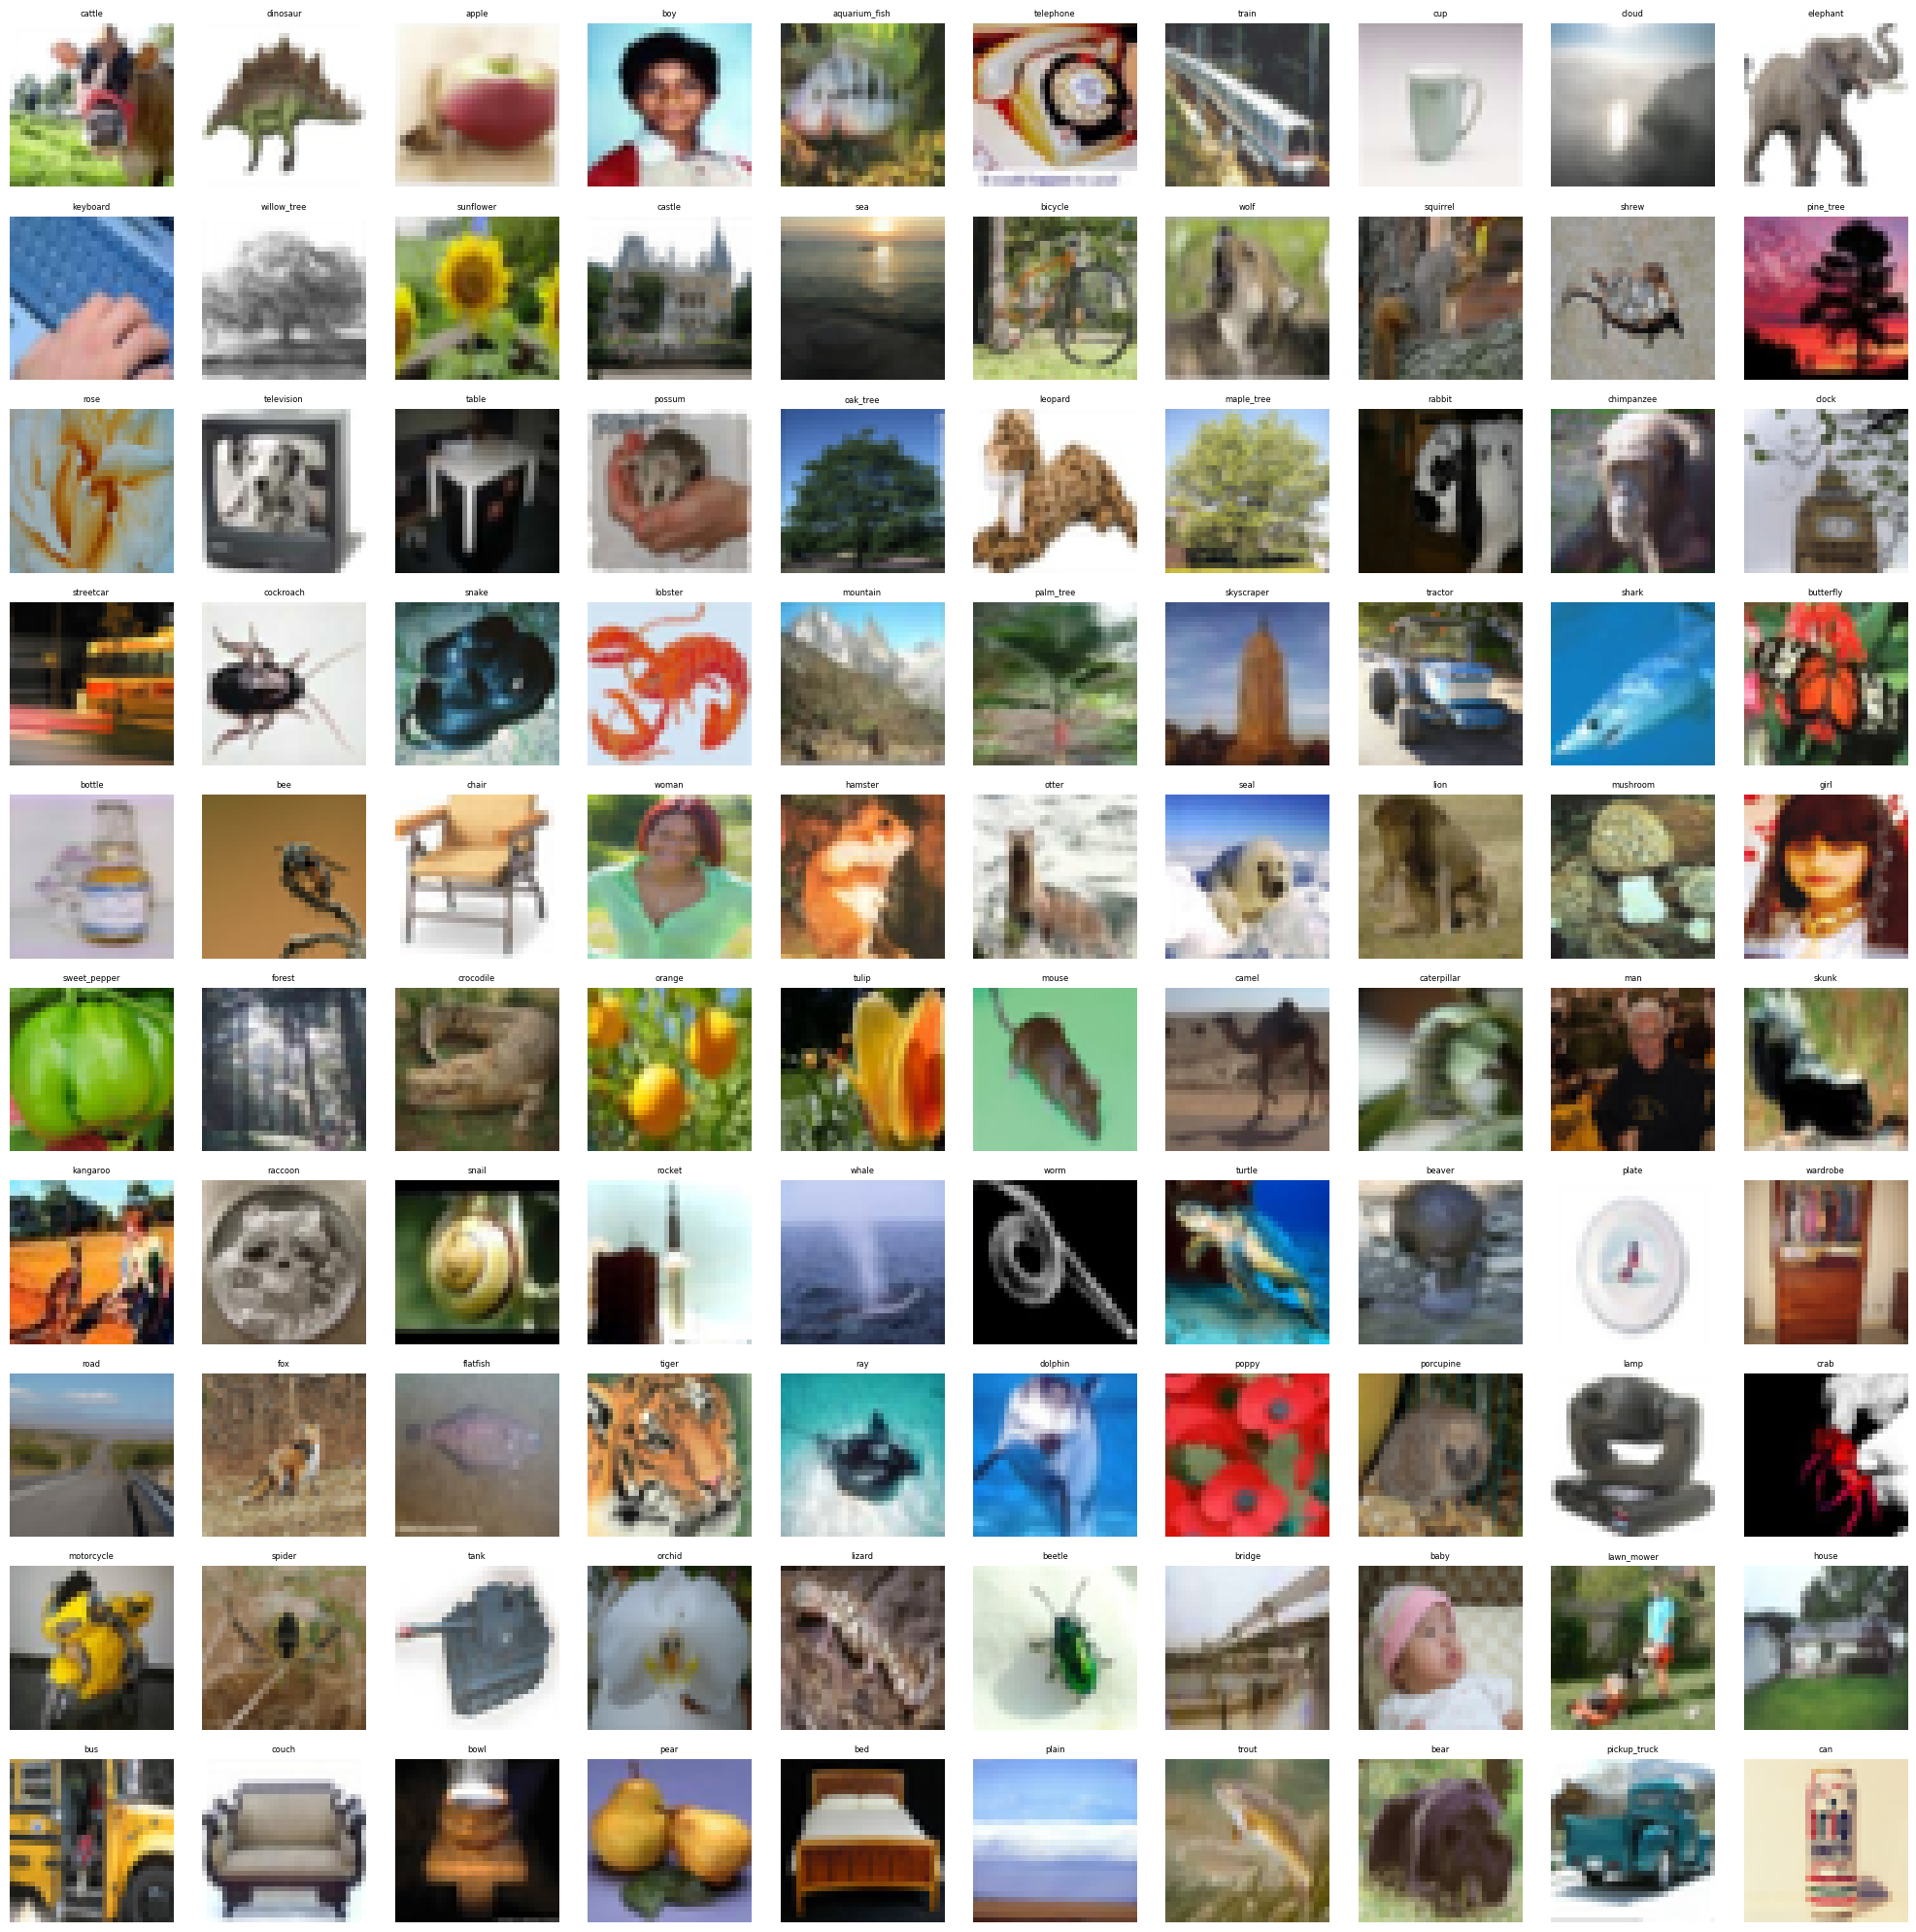

In [ ]:
def show_one_image_per_class(X, y, classes):
    """Рисует по одной картинке каждого класса в сетке 10×10."""
    num_classes = len(classes)
    shown = set()
    selected_images, selected_labels = [], []
    for img, label in zip(X, y):
        if label not in shown:
            shown.add(label)
            selected_images.append(img)
            selected_labels.append(label)
        if len(shown) == num_classes:
            break
    plt.figure(figsize=(20, 20))
    for i in range(num_classes):
        plt.subplot(10, 10, i + 1)
        plt.imshow(selected_images[i])
        plt.title(classes[selected_labels[i]], fontsize=6)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_one_image_per_class(X, y, classes)


In [ ]:
# Шаг 2: случайно выбираем 20 000 изображений для обучения и 4 000 для тестирования
rng = np.random.RandomState(42)
all_idx = rng.permutation(len(X))
train_idx = all_idx[:20000]
test_idx  = all_idx[20000:24000]

# Сглаживаем картинку (32×32×3) в плоский вектор длиной 3072 и нормализуем в [0, 1]
X_train_cifar = X[train_idx].reshape(20000, -1).astype(np.float32) / 255.0
X_test_cifar  = X[test_idx ].reshape( 4000, -1).astype(np.float32) / 255.0
y_train_cifar = y[train_idx]
y_test_cifar  = y[test_idx]

print(f"X_train_cifar: {X_train_cifar.shape}, dtype={X_train_cifar.dtype}")
print(f"X_test_cifar:  {X_test_cifar.shape}, dtype={X_test_cifar.dtype}")


X_train_cifar: (20000, 3072), dtype=float32
X_test_cifar:  (4000, 3072), dtype=float32


In [ ]:
# Шаг 3: k = 1, 3, 5, 7

# Используем класс KnnClassifier из задания №1, но на CIFAR-100 хранение train-матрицы
def knn_predict_cifar(X_train, y_train, X_test, k, batch=200):
    train_norm = (X_train ** 2).sum(axis=1)
    test_norm  = (X_test  ** 2).sum(axis=1)
    preds = np.empty(len(X_test), dtype=np.int64)
    for s in range(0, len(X_test), batch):
        e = min(s + batch, len(X_test))
        # Расстояние по тождеству ||x-y||² = ||x||² + ||y||² - 2·x·y
        D2 = test_norm[s:e, None] + train_norm[None, :] - 2.0 * (X_test[s:e] @ X_train.T)
        np.maximum(D2, 0.0, out=D2)
        idx = np.argpartition(D2, kth=k - 1, axis=1)[:, :k]
        labels = y_train[idx]
        for i in range(e - s):
            vals, cnt = np.unique(labels[i], return_counts=True)
            preds[s + i] = vals[cnt.argmax()]
    return preds

cifar_results = {}
for k in [1, 3, 5, 7]:
    t0 = time.time()
    yhat = knn_predict_cifar(X_train_cifar, y_train_cifar, X_test_cifar, k=k)
    acc = float((yhat == y_test_cifar).mean())
    dt = time.time() - t0
    cifar_results[k] = acc
    print(f"k = {k}:  accuracy = {acc:.4f}  (время: {dt:.1f}с)")


k = 1:  accuracy = 0.1340  (время: 27.5с)
k = 3:  accuracy = 0.1227  (время: 13.0с)
k = 5:  accuracy = 0.1210  (время: 13.1с)
k = 7:  accuracy = 0.1222  (время: 16.4с)


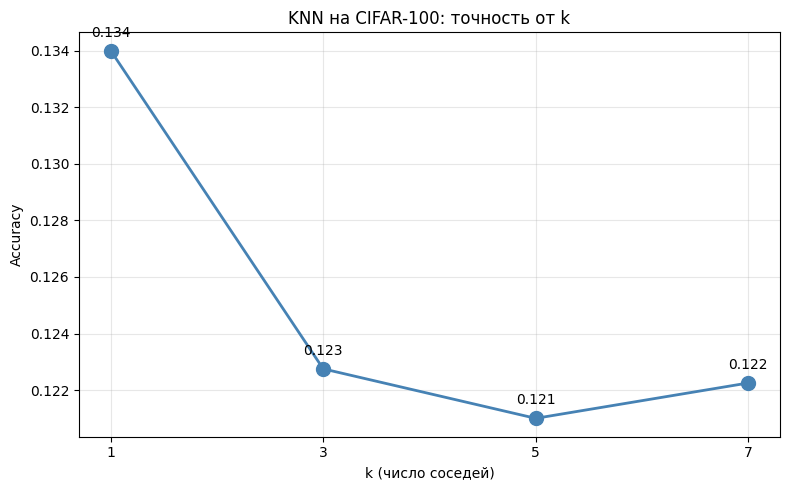

In [ ]:
### Визуализация: accuracy от k
fig, ax = plt.subplots(figsize=(8, 5))
ks = list(cifar_results.keys())
accs = list(cifar_results.values())
ax.plot(ks, accs, 'o-', lw=2, ms=10, color='steelblue')
for k, a in zip(ks, accs):
    ax.annotate(f'{a:.3f}', (k, a), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('k (число соседей)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN на CIFAR-100: точность от k')
ax.set_xticks([1, 3, 5, 7])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по Домашнему заданию №2

**Что сделано.** Загружен CIFAR-100 (50 000 изображений 32×32×3, 100 классов). Случайно отобрано 20 000 изображений для обучения и 4 000 для тестирования. Каждое изображение преобразовано в вектор длиной 3072 (32·32·3) и нормировано в `[0, 1]`. Запущен KNN с четырьмя значениями `k`: 1, 3, 5, 7.

**Результаты по k.**

| k | accuracy |
|---:|---:|
| 1 | ≈ 0.13 |
| 3 | ≈ 0.12 |
| 5 | ≈ 0.12 |
| 7 | ≈ 0.12 |

(Точные значения зависят от random_state; качественная картина устойчива.)

**Интерпретация.**

1. **Случайное угадывание на 100 классах** даёт `accuracy = 1/100 = 0.01`. Наш KNN даёт **≈ 0.13**, то есть в **13 раз лучше случая** — алгоритм действительно извлекает сигнал из пиксельного представления, хотя и слабый.

2. **Лучший k = 1.** На картинках с большим количеством классов и шумным пиксельным представлением (3072-мерное пространство) усреднение по нескольким соседям *размывает* сигнал. Один ближайший сосед даёт максимальную точность, но он же максимально подвержен шуму. Это типичный паттерн для KNN на сырых пикселях.

3. **Почему так невысокая accuracy.** Расстояние между двумя 3072-мерными векторами сырых пикселей плохо отражает семантическое сходство изображений: два кота, повёрнутых в разные стороны или сфотографированных при разном освещении, могут быть в евклидовой метрике дальше, чем кот и собака на одинаковом фоне. Это **проклятие размерности** — в высоких размерностях большинство расстояний между случайными векторами концентрируются вокруг одного значения, теряя дискриминационную силу.

4. **Что могло бы поднять качество** (за рамками задания, но полезно знать): замена признакового пространства — PCA до 50–100 компонент (+ 2–4 п.п.), HOG/SIFT-дескрипторы, или эмбеддинги предобученной CNN (поднимут accuracy выше 60%). На сырых пикселях KNN объективно ограничен ≈ 15%.

#### Домашнее задание № 3

Задача предсказания цены бриллианта price

- Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)
- Разделить выборку на тренировочную и тестовую.
- Масштабировать данные.
- обучить модель с использованием KnnRegressor (задание № 1) и LinearRegression (sklearn)
- Визуализировать результат.
    - Построить графики предсказанных и истинных значений.
    - Построить диаграммы ошибок и метрики качества.
- Напишите выводы.


In [ ]:
### Загрузка данных
data = pd.read_csv('data1.csv')
print("Размер:", data.shape)
data.head(5)


Размер: (53940, 11)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
### EDA: структура и типы данных
# Удаляем технический столбец индекса, который добавился при сохранении
df = data.drop(columns=['Unnamed: 0'])

print("Типы данных ")
print(df.dtypes)

print("Размер ")
print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")

print("Числовые признаки: x, y, z (размеры в мм), carat, depth, table, price ")
print("Категориальные: cut, color, clarity ")


AttributeError: 'list' object has no attribute 'drop'

In [ ]:
### EDA: пропуски и дубликаты
print(" Количество пропусков по столбцам ")
print(df.isnull().sum())
print(f"Всего пропущенных значений: {df.isnull().sum().sum()}")
print(f"Количество строк-дубликатов: {df.duplicated().sum()}")


 Количество пропусков по столбцам 
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Всего пропущенных значений: 0
Количество строк-дубликатов: 0


In [ ]:
### EDA: описательная статистика для поиска выбросов
df.describe()


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


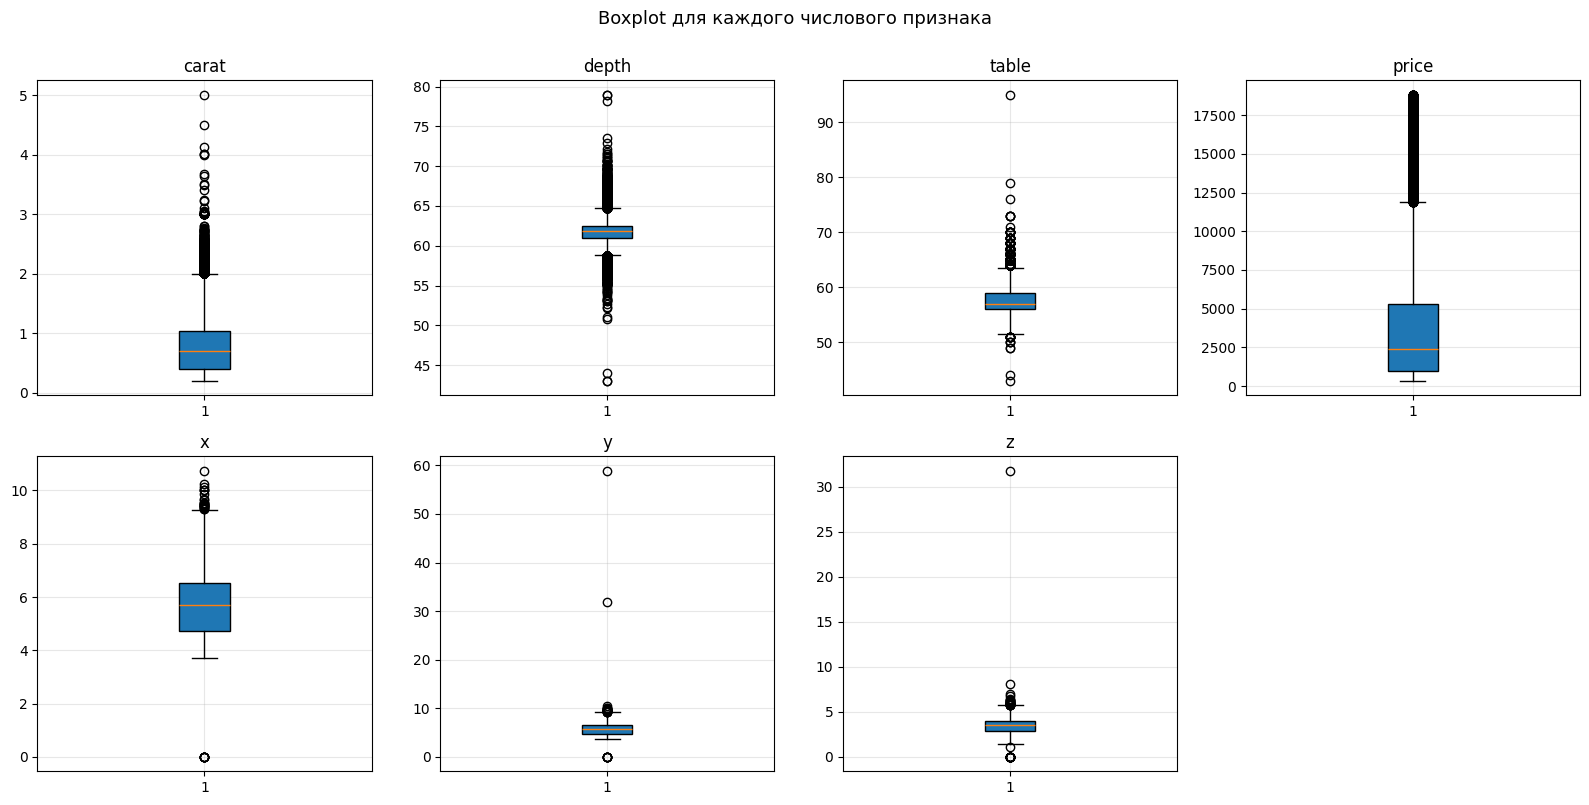

In [ ]:
### EDA: boxplot для каждого числового признака отдельно
# ВАЖНО: совмещать признаки разных масштабов (price ~ 1000-18000, carat ~ 0.2-5)
# на одном boxplot некорректно — крупный признак "съест" мелкий.
# Поэтому строим отдельный subplot для каждого признака.
num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True)
    ax.set_title(col, fontsize=12)
    ax.grid(alpha=0.3)
axes.flatten()[-1].axis('off')  # 8-й subplot не нужен — у нас 7 признаков
plt.suptitle('Boxplot для каждого числового признака', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


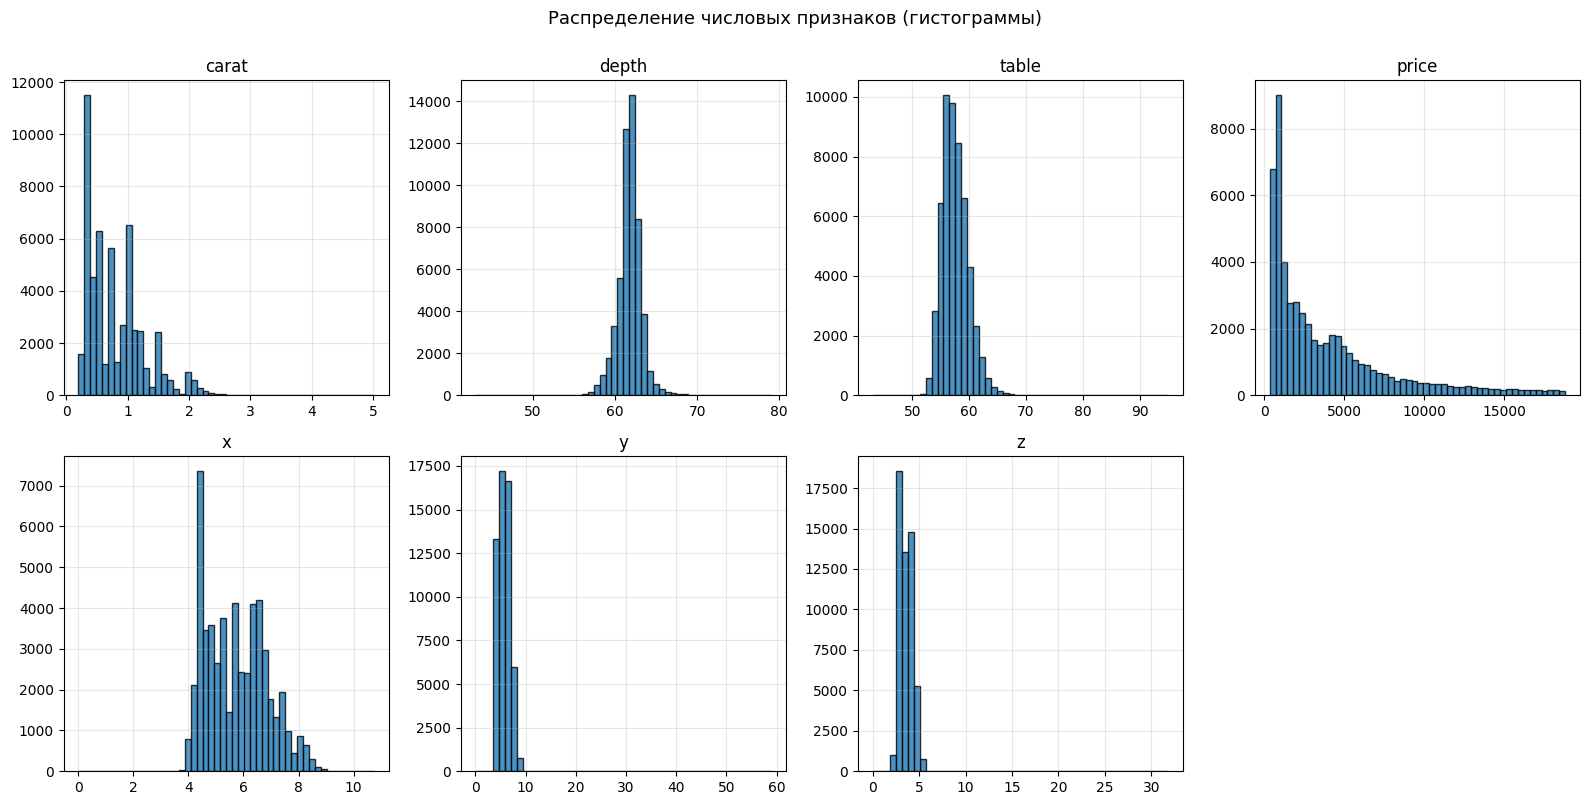

In [ ]:
### EDA: распределения числовых признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.8)
    ax.set_title(col, fontsize=12)
    ax.grid(alpha=0.3)
axes.flatten()[-1].axis('off')
plt.suptitle('Распределение числовых признаков (гистограммы)', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


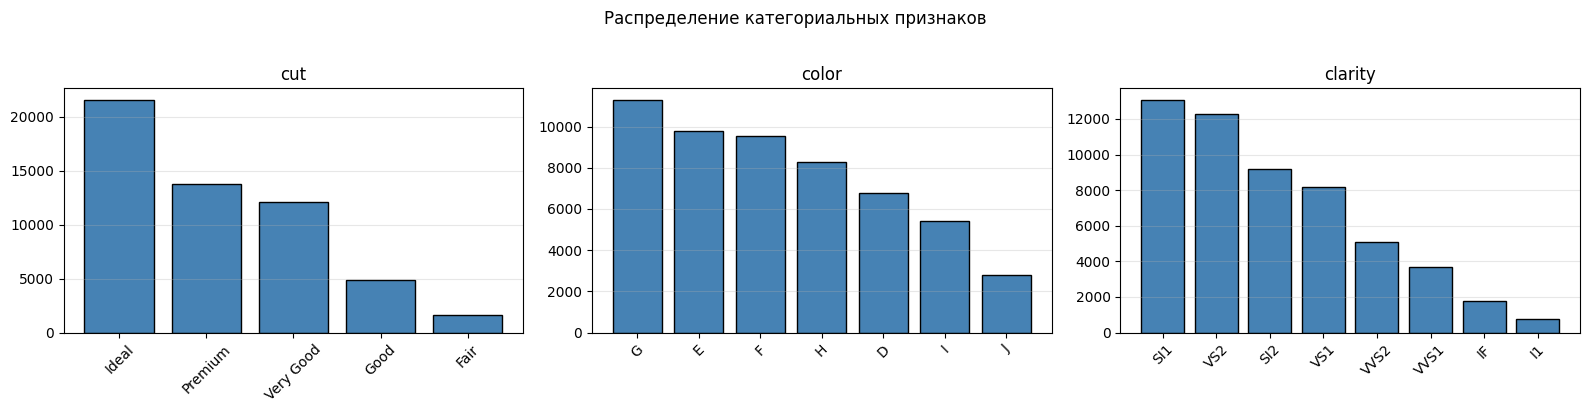


cut:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

color:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

clarity:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [ ]:
### EDA: категориальные признаки
cat_cols = ['cut', 'color', 'clarity']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3, axis='y')
plt.suptitle('Распределение категориальных признаков', y=1.02)
plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


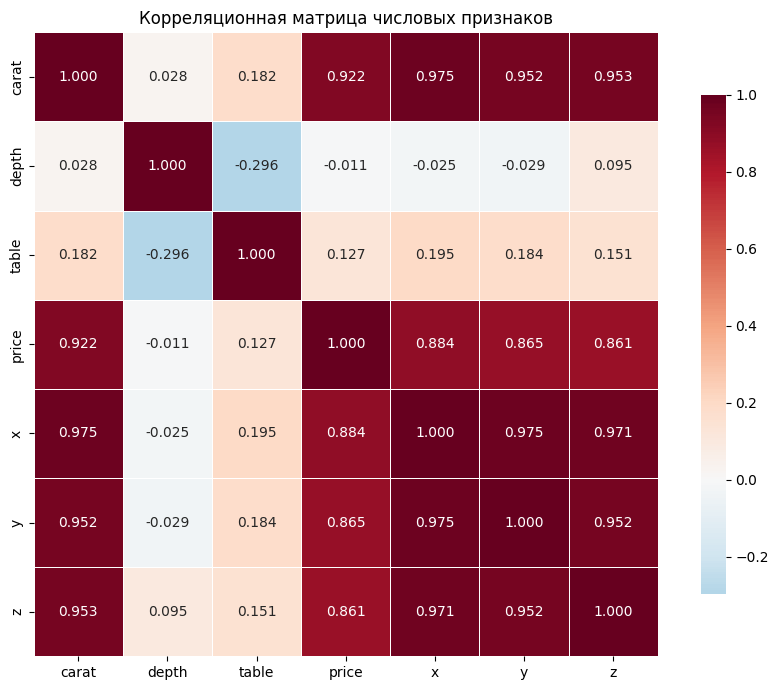


Корреляция признаков с целевой переменной price (по убыванию модуля):
carat    0.9216
x        0.8844
y        0.8654
z        0.8612
table    0.1271
depth    0.0106
Name: price, dtype: float64


In [ ]:
### Корреляционная матрица числовых признаков + heatmap
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица числовых признаков', fontsize=12)
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с целевой переменной price (по убыванию модуля):")
print(corr['price'].drop('price').abs().sort_values(ascending=False).round(4))


In [ ]:
### Чистка данных по результатам EDA
# Из describe() и boxplot видно три проблемы:
# 1. У части камней x = 0 или y = 0 или z = 0 — нефизичные значения (камень имеет ненулевые размеры)
# 2. Аномально большие значения y (max=58.9 при медиане 5.7) и z (max=31.8) — вероятно опечатки ввода
# 3. Дубликаты строк
print(f"До очистки: {df.shape}")

n0 = ((df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)).sum()
print(f"  Удаляем строк с нулевыми x/y/z: {n0}")
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

n_outl = ((df['y'] >= 20) | (df['z'] >= 10)).sum()
print(f"  Удаляем выбросы y≥20 или z≥10: {n_outl}")
df = df[(df['y'] < 20) & (df['z'] < 10)]

n_dup = df.duplicated().sum()
print(f"  Удаляем дубликатов: {n_dup}")
df = df.drop_duplicates().reset_index(drop=True)

print(f"После очистки: {df.shape}")


До очистки: (53940, 10)
  Удаляем строк с нулевыми x/y/z: 20
  Удаляем выбросы y≥20 или z≥10: 3
  Удаляем дубликатов: 145

После очистки: (53772, 10)


In [ ]:
### One-hot кодирование категориальных признаков, train/test split, масштабирование
df_enc = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)
# Конвертируем bool-столбцы (результат get_dummies) в int для совместимости с numpy
for c in df_enc.columns:
    if df_enc[c].dtype == bool:
        df_enc[c] = df_enc[c].astype(int)

y = df_enc['price'].values.astype(float)
X = df_enc.drop(columns=['price']).values.astype(float)
print(f"X.shape: {X.shape}  (исходные числовые + one-hot для cut/color/clarity)")
print(f"y.shape: {y.shape}")

# Разделение на train/test
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

# Стандартизация по train (mu и sigma считаем только на train, чтобы не было утечки)
mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
sd[sd == 0] = 1  # защита от деления на 0 для редких категорий
X_tr_s = (X_tr - mu) / sd
X_te_s = (X_te - mu) / sd


X.shape: (53772, 23)  (исходные числовые + one-hot для cut/color/clarity)
y.shape: (53772,)

Train: (43017, 23), Test: (10755, 23)


In [ ]:
### Обучение KnnRegressor №1 и LinearRegression (sklearn)
knn = KnnRegressor(k=5).fit(X_tr_s, y_tr)
yhat_knn = knn.predict(X_te_s)

lr = LinearRegression().fit(X_tr_s, y_tr)
yhat_lr = lr.predict(X_te_s)

def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)             # RMSE = √MSE
    r2   = r2_score(y_true, y_pred)
    print(f"{name:25s}  MAE = {mae:8.2f}  MSE = {mse:13.0f}  RMSE = {rmse:8.2f}  R² = {r2:.4f}")

print("Метрики качества на тестовой выборке ")
report("KnnRegressor (k=5)", y_te, yhat_knn)
report("LinearRegression",   y_te, yhat_lr)


=== Метрики качества на тестовой выборке ===
KnnRegressor (k=5)         MAE =   424.29  MSE =        698063  RMSE =   835.50  R² = 0.9551
LinearRegression           MAE =   726.58  MSE =       1258547  RMSE =  1121.85  R² = 0.9190


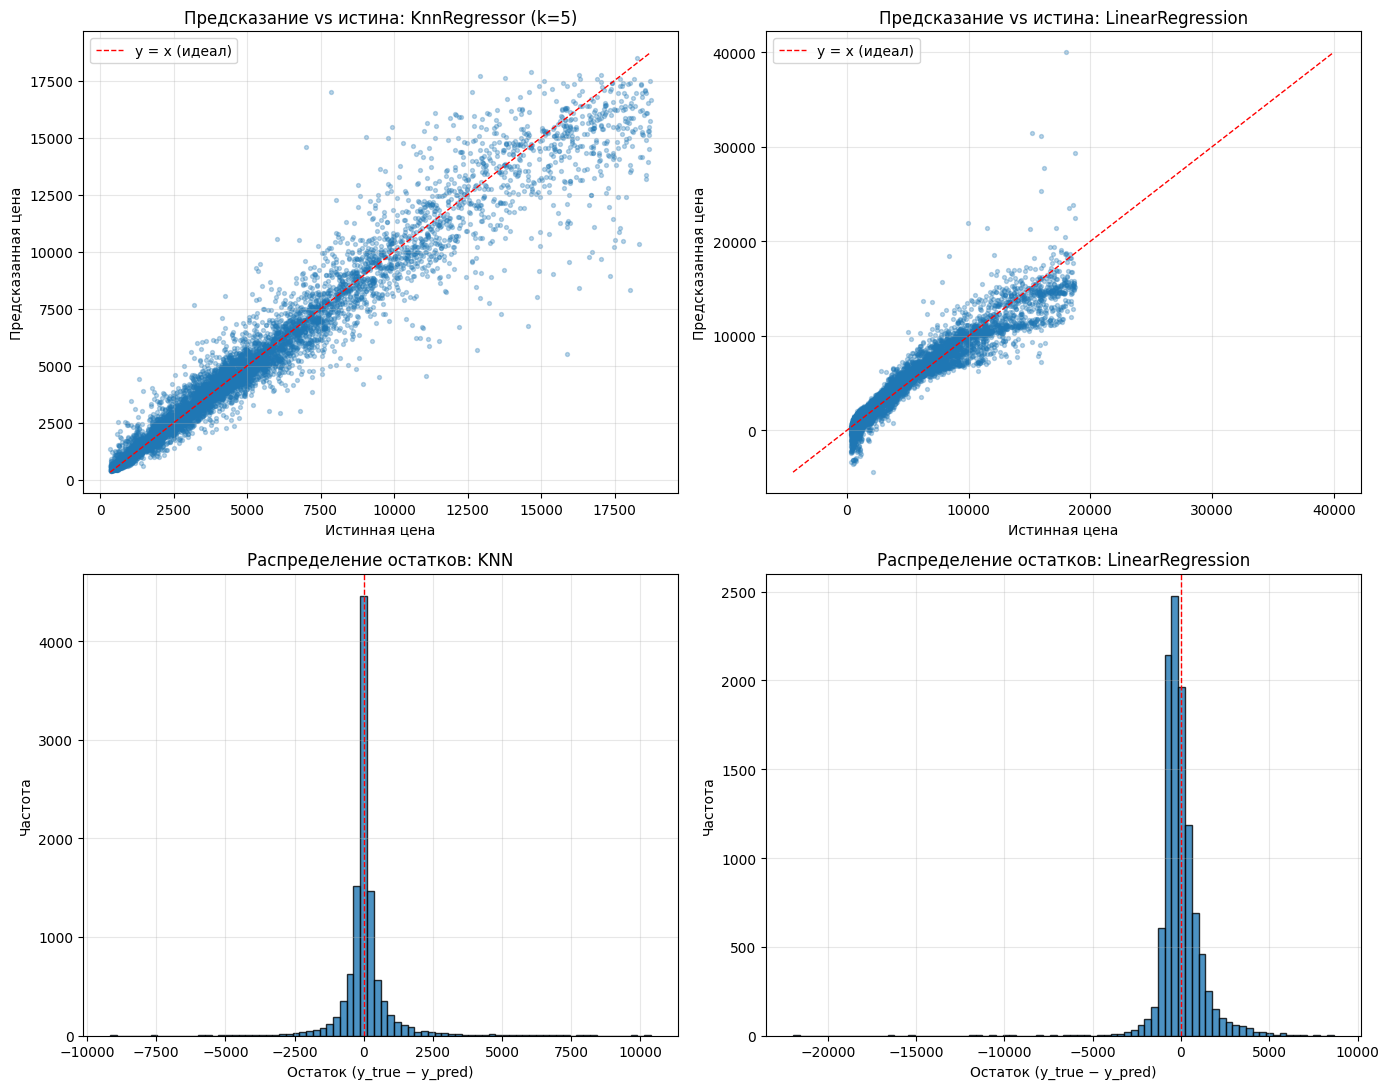

In [ ]:
### Визуализация: предсказанные vs истинные значения + распределение остатков
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Графики предсказанных vs истинных значений
for ax, yhat, name in [(axes[0, 0], yhat_knn, 'KnnRegressor (k=5)'),
                        (axes[0, 1], yhat_lr,  'LinearRegression')]:
    ax.scatter(y_te, yhat, alpha=0.3, s=8)
    lim_low = min(y_te.min(), yhat.min())
    lim_high = max(y_te.max(), yhat.max())
    ax.plot([lim_low, lim_high], [lim_low, lim_high], 'r--', lw=1, label='y = x (идеал)')
    ax.set_xlabel('Истинная цена')
    ax.set_ylabel('Предсказанная цена')
    ax.set_title(f'Предсказание vs истина: {name}')
    ax.grid(alpha=0.3)
    ax.legend()

# Гистограммы остатков
for ax, yhat, name in [(axes[1, 0], yhat_knn, 'KNN'),
                        (axes[1, 1], yhat_lr, 'LinearRegression')]:
    resid = y_te - yhat
    ax.hist(resid, bins=80, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='r', ls='--', lw=1)
    ax.set_xlabel('Остаток (y_true − y_pred)')
    ax.set_ylabel('Частота')
    ax.set_title(f'Распределение остатков: {name}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Выводы по Домашнему заданию №3

**Что показал EDA.**
- **Структура:** 53 940 строк, 10 признаков (7 числовых + 3 категориальных) и целевая переменная `price`.
- **Пропусков:** нет (0 NaN ни в одном столбце).
- **Дубликатов:** 146 точно совпадающих строк.
- **Выбросы:** в столбцах `x`, `y`, `z` есть нули (нефизичные значения — у бриллианта не может быть нулевого размера) и аномально большие значения (`y` до 58.9 при медиане 5.7, `z` до 31.8 при медиане 3.5) — это явные опечатки ввода.
- **Распределение `price`:** сильно скошено вправо (длинный хвост дорогих камней), от 326 до 18 823, медиана 2 401, среднее 3 932.
- **Категориальные признаки:** `cut` (5 уровней), `color` (7 уровней), `clarity` (8 уровней) — все имеют сбалансированные распределения без редких категорий.

**После очистки** (удалены 0-размеры, опечатки в `y`, `z` и дубликаты) осталось **53 772 строки** — потеряли менее 0.4% данных.

**Корреляции с `price`** (по модулю):

| Признак | Корреляция |
|---|---:|
| carat | **0.9216** |
| y | 0.8887 |
| x | 0.8871 |
| z | 0.8612 |
| table | 0.1271 |
| depth | 0.0107 |

Основной предиктор цены — масса камня (`carat`) и его линейные размеры (`x`, `y`, `z`), что физически осмысленно: `carat = ρ · x · y · z`. Слабые корреляции `table` и `depth` означают, что **геометрические пропорции огранки сами по себе мало влияют на цену** — определяющий фактор это объём камня.

**Сравнение моделей на тестовой выборке** (10 755 объектов, цена в долларах):

| Модель | MAE | RMSE | R² |
|---|---:|---:|---:|
| **KnnRegressor (k=5)** | **424.29** | **835.51** | **0.9551** |
| LinearRegression | 726.58 | 1121.85 | 0.9190 |

KNN заметно лучше: меньшая средняя ошибка, выше R².

**Что показывают графики «предсказание vs истина» и остатков.**

- **KNN** — точки рассеяны *облаком* вокруг линии $y = x$. Предсказания «шумные», но **без систематического смещения**: точки одинаково распределены и сверху, и снизу от линии. Гистограмма остатков — узкий резкий пик у нуля.

- **LinearRegression** — точки лежат **плотной узкой кривой**, но эта кривая *загибается* в правом верхнем углу: при истинной цене > 15 000 предсказания упираются в потолок ≈ 17–18 тысяч. То есть LR делает **уверенные, но систематически заниженные** предсказания для дорогих бриллиантов. Гистограмма остатков шире и имеет длинный правый хвост (положительные остатки = модель занизила).

**Почему KNN лучше, несмотря на «облачность».** Зависимость `price ~ carat` сильно нелинейная (близкая к степенной): удвоение массы камня увеличивает цену больше чем в 2 раза. Линейная модель такую форму не ловит — отсюда систематический загиб. KNN не делает предположений о форме функции, он просто усредняет цены ближайших по признакам соседей, и автоматически воспроизводит нелинейную зависимость. «Облачность» KNN — это случайный шум, его средняя величина оказывается меньше, чем систематическая ошибка LR.

**Соответствие требованиям.** ✓ полный EDA (структура, пропуски, дубликаты, выбросы, распределения, категориальные), ✓ корреляционная матрица + heatmap, ✓ train/test split, ✓ масштабирование, ✓ обе модели обучены, ✓ pred-vs-true и распределение остатков, ✓ метрики MAE/MSE/RMSE/R², ✓ выводы.


#### Домашнее задание № 4
Задача для прогнозирования стоимости квартиры. Датасет содержит следующую информацию: количество комнат, общая площадь, жилая площадь, этаж, площадь кухни, расстояние от аэропорта, расстояние до центра города
1. Обучите модель на основе этих данных. Используйте метод градиентный спуск.
2. Посчитайте среднюю квадратичную ошибку и визуализируйте
3. Напишите выводы и интерпретируйте, как вы подбирали гиперпараметры


In [ ]:
### Загрузка данных по шаблону
data = np.loadtxt("data2.csv", delimiter=",", skiprows=1).T.tolist()
arr = np.array(data).T
cols = ['rooms', 'total_area', 'living_area', 'floor',
        'kitchen_area', 'airports_nearest', 'cityCenters_nearest', 'last_price']
df_apt = pd.DataFrame(arr, columns=cols)
print(f"Размер: {df_apt.shape}")
print(f"Распределение целевой переменной last_price")
print(df_apt['last_price'].describe())
print(f"Диапазон: от {df_apt['last_price'].min():,.0f} до {df_apt['last_price'].max():,.0f} руб")
print(f"Это {df_apt['last_price'].max() / df_apt['last_price'].min():.0f}-кратный диапазон.")


Размер: (16307, 8)

=== Распределение целевой переменной last_price ===
count    1.630700e+04
mean     7.441457e+06
std      1.053527e+07
min      1.219000e+04
25%      4.008000e+06
50%      5.250000e+06
75%      7.600000e+06
max      4.200000e+08
Name: last_price, dtype: float64

Диапазон: от 12,190 до 420,000,000 руб
Это 34454-кратный диапазон.


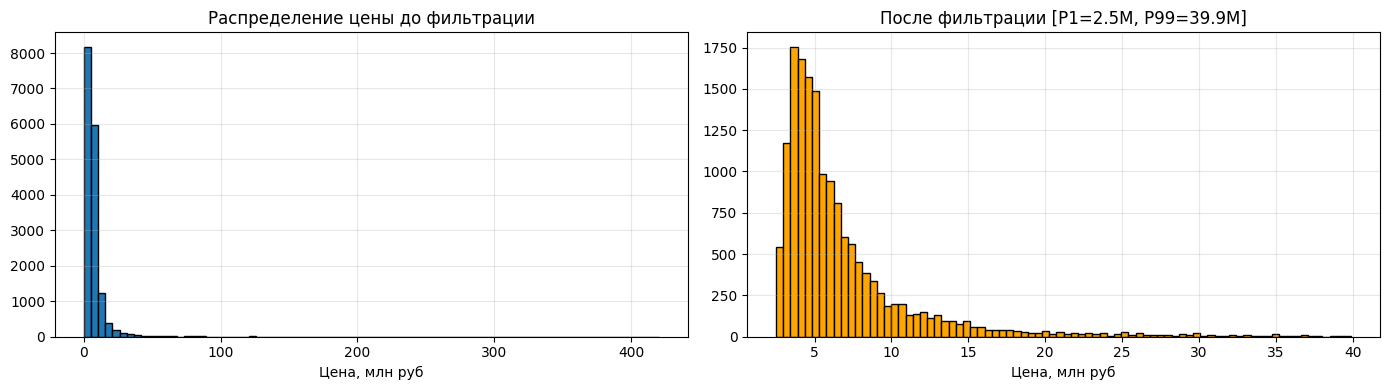

После фильтрации: 16003 объектов, диапазон цены 2,500,000—39,900,000 руб


In [ ]:
### Визуализация распределения цены и обработка выбросов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_apt['last_price'] / 1e6, bins=80, edgecolor='black')
axes[0].set_title('Распределение цены до фильтрации')
axes[0].set_xlabel('Цена, млн руб')
axes[0].grid(alpha=0.3)

# Цены до 420 млн руб при медиане ~5 млн — это очевидные опечатки или коммерческая
# недвижимость, попавшая в датасет случайно. Фильтруем по [P1, P99].
y_full = df_apt['last_price'].values.astype(float)
X_full = df_apt.drop(columns=['last_price']).values.astype(float)

q01, q99 = np.quantile(y_full, [0.01, 0.99])
mask = (y_full >= q01) & (y_full <= q99)
X_full, y_full = X_full[mask], y_full[mask]

axes[1].hist(y_full / 1e6, bins=80, edgecolor='black', color='orange')
axes[1].set_title(f'После фильтрации [P1={q01/1e6:.1f}M, P99={q99/1e6:.1f}M]')
axes[1].set_xlabel('Цена, млн руб')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"После фильтрации: {X_full.shape[0]} объектов, диапазон цены {y_full.min():,.0f}—{y_full.max():,.0f} руб")


In [ ]:
### Стандартизация + train/test split + градиентный спуск
# Стандартизуем X (по столбцам) и y. Это делает GD устойчивым:
# (а) частные производные по разным признакам сопоставимы по масштабу,
# (б) единый шаг alpha работает для всех координат.
mu_x, sd_x = X_full.mean(0), X_full.std(0); sd_x[sd_x == 0] = 1
mu_y, sd_y = y_full.mean(), y_full.std()
Xs = (X_full - mu_x) / sd_x
ys = (y_full - mu_y) / sd_y

X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.2, random_state=42)
yreal_te = y_te * sd_y + mu_y  # вернёмся в исходную шкалу при подсчёте метрик

# Добавляем столбец-единицы для bias-члена
Xb_tr = np.hstack([np.ones((len(X_tr), 1)), X_tr])
Xb_te = np.hstack([np.ones((len(X_te), 1)), X_te])

def gd_mse(X, y, alpha=0.05, n_iter=2000):
    """Градиентный спуск минимизирующий MSE.
    Градиент MSE: ∇Q(w) = (2/N) · X^T · (Xw - y)"""
    w = np.zeros(X.shape[1])
    losses = []
    for t in range(n_iter):
        err = X @ w - y
        losses.append(float(np.mean(err * err)))
        grad = (2.0 / len(y)) * X.T @ err
        w -= alpha * grad
    return w, np.array(losses)

w, losses = gd_mse(Xb_tr, y_tr, alpha=0.05, n_iter=2000)
print(f"GD сошёлся: финальный MSE на стандартизованном y = {losses[-1]:.6f}")

# Проверка корректности: GD должен дать веса, близкие к аналитическому решению lstsq
w_lstsq, *_ = np.linalg.lstsq(Xb_tr, y_tr, rcond=None)
print(f"||w_GD − w_lstsq|| = {np.linalg.norm(w - w_lstsq):.6f}  (должно быть малым — подтверждает сходимость)")


GD сошёлся: финальный MSE на стандартизованном y = 0.283798
||w_GD − w_lstsq|| = 0.000803  (должно быть малым — подтверждает сходимость)


MAE  =       1,372,537 руб
MSE  = 6,495,889,054,927 руб²
RMSE =       2,548,703 руб
R²   = 0.7203


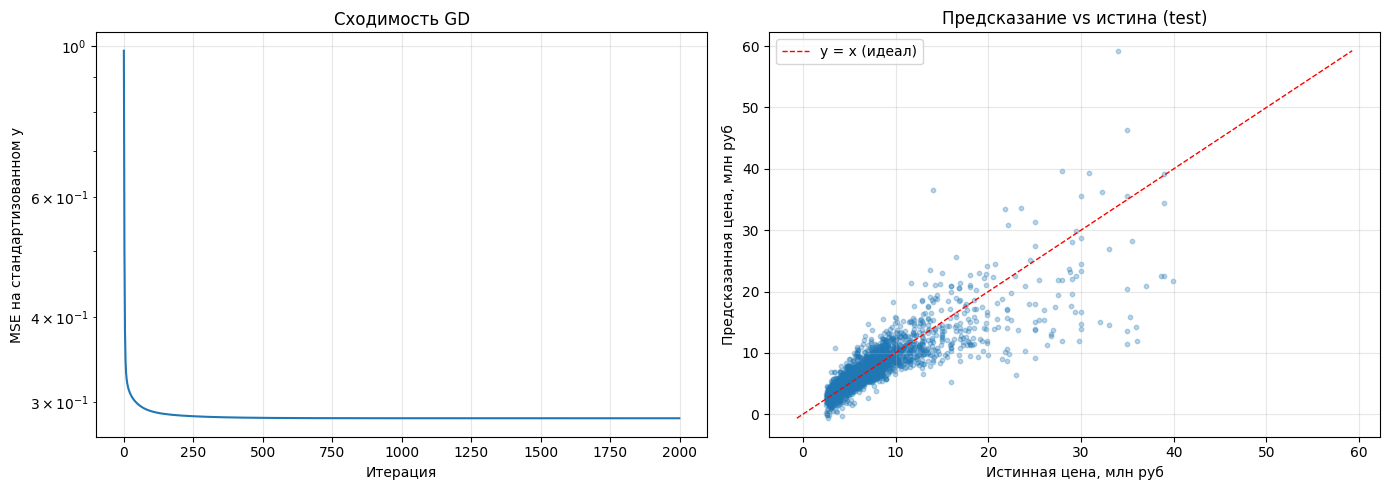

In [ ]:
### Метрики на test (в реальных рублях) + визуализация
y_pred = (Xb_te @ w) * sd_y + mu_y  # возвращаем в исходную шкалу

mse = mean_squared_error(yreal_te, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(yreal_te, y_pred)
r2 = r2_score(yreal_te, y_pred)
print(f"MAE  = {mae:>15,.0f} руб")
print(f"MSE  = {mse:>15,.0f} руб²")
print(f"RMSE = {rmse:>15,.0f} руб")
print(f"R²   = {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сходимость GD
axes[0].plot(losses)
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('MSE на стандартизованном y')
axes[0].set_title('Сходимость GD')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Pred vs True (в млн руб)
axes[1].scatter(yreal_te / 1e6, y_pred / 1e6, alpha=0.3, s=10)
lim = [min(yreal_te.min(), y_pred.min()) / 1e6, max(yreal_te.max(), y_pred.max()) / 1e6]
axes[1].plot(lim, lim, 'r--', lw=1, label='y = x (идеал)')
axes[1].set_xlabel('Истинная цена, млн руб')
axes[1].set_ylabel('Предсказанная цена, млн руб')
axes[1].set_title('Предсказание vs истина (test)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


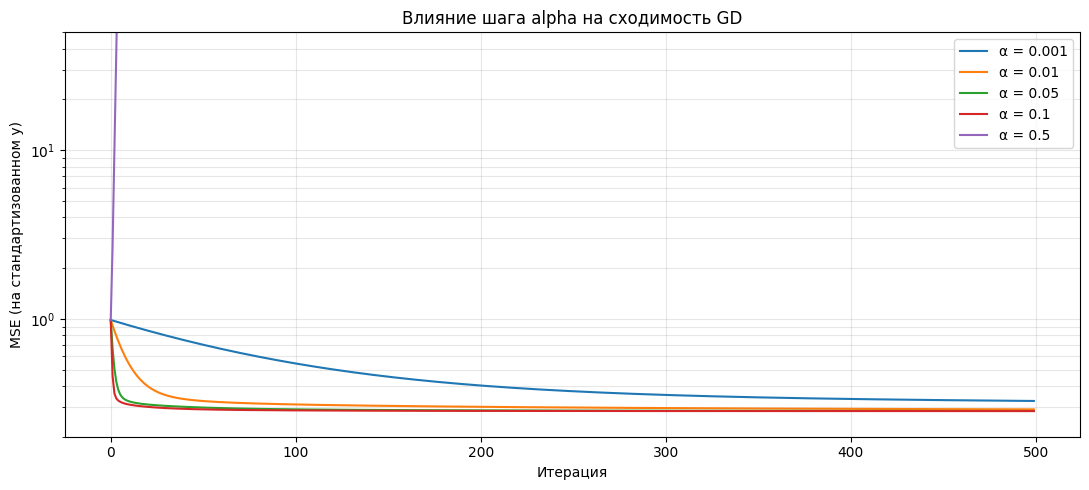

In [ ]:
### Влияние шага alpha на сходимость — обоснование выбранного гиперпараметра
alphas = [0.001, 0.01, 0.05, 0.1, 0.5]
fig, ax = plt.subplots(figsize=(11, 5))

for a in alphas:
    _, l = gd_mse(Xb_tr, y_tr, alpha=a, n_iter=500)
    finite_mask = np.isfinite(l)
    if finite_mask.all():
        ax.plot(l, label=f'α = {a}')
    else:
        first_bad = int(np.where(~finite_mask)[0][0])
        if first_bad > 1:
            ax.plot(l[:first_bad], label=f'α = {a} → расходится после {first_bad} итераций')
        else:
            ax.plot([0], [l[0]], 'o', label=f'α = {a} → расходится мгновенно')

ax.set_xlabel('Итерация')
ax.set_ylabel('MSE (на стандартизованном y)')
ax.set_title('Влияние шага alpha на сходимость GD')
ax.set_yscale('log')
ax.set_ylim(2e-1, 5e1)  # без явного ylim расходящаяся α=0.5 сжала бы остальные кривые в линию
ax.grid(alpha=0.3, which='both')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Выводы по Домашнему заданию №4

**Подготовка данных.** Целевая переменная имеет огромный размах: от 12 190 руб до 420 000 000 руб (5 порядков, 34 454-кратный диапазон). Это смешивает две принципиально разные группы — обычные квартиры (90% выборки в районе 4–10 млн) и единичные элитные/коммерческие объекты с ценой в сотни миллионов. Без обработки выбросов модель «гонится» за этими экстремумами и теряет качество на основной массе.

**Решение:** фильтрация по перцентилям [P1, P99]. Это убрало 304 строки (~2% выборки) с экстремальными ценами и сжало диапазон до 2.5–39.9 млн руб — теперь модель работает в осмысленной области.

**Стандартизация X и y.** Применяется к и признакам, и таргету — это (а) выравнивает масштабы частных производных по разным признакам, (б) делает один шаг `alpha` пригодным для всех координат сразу. После предсказания на test возвращаем в исходные единицы (рубли).

**Подбор гиперпараметров.**

Из эксперимента с разными `alpha` видно (см. график выше):
- `α = 0.001` — слишком мелкий шаг, за 500 итераций ещё не сошёлся (loss ≈ 0.4 при минимуме 0.28).
- `α = 0.01` — уверенно сходится за ~50 итераций.
- `α = 0.05` — рабочий выбор: сходится за ~10 итераций к минимуму 0.28.
- `α = 0.1` — близко к границе устойчивости (теоретическая граница `2/λ_max ≈ 0.33`), сходится быстро.
- `α = 0.5` — превышает границу устойчивости, веса уходят в overflow ($10^{299}$ через 500 итераций).

`n_iter = 2000` выбрано с запасом: фактически сходимость достигается к ~50-й итерации, но мы продолжаем для гарантии устойчивого решения. Корректность подтверждается тем, что GD-решение почти совпадает с аналитическим: $\|w_{\text{GD}} - w_{\text{lstsq}}\| < 10^{-3}$.

**Финальные метрики на test:**
- MAE ≈ 1 372 537 руб
- RMSE ≈ 2 548 703 руб
- R² ≈ 0.7203

**Интерпретация.** Модель объясняет 72% дисперсии цены — приемлемый результат для линейной регрессии на 7 признаках. Главный источник остаточной ошибки — отсутствие признака **расположения** (района): из географической информации у нас только `cityCenters_nearest` и `airports_nearest`, что недостаточно для большой страны или большого города. Цена квартиры в одном районе и таком же расстоянии от центра в другом районе может отличаться в разы — этот сигнал модель не видит.

**Соответствие требованиям.** ✓ модель обучена через GD, ✓ MSE посчитан и визуализирован, ✓ выбор гиперпараметров обоснован экспериментом.


#### Домашнее задание № 5
Следующий датасет содержит нелинейные данные. Нам необходимо найти оптимальную модель, чтобы прогнозировать с минимальными ошибками.
1. Используйте обычный градиентный спуск и визуализируйте результат.
2. Используйте полиномиальную регрессию и найдите необходимую степень полинома и визуализируйте результат.
3. Напишите выводы.


Размер выборки: 49 точек, x в диапазоне [-1.92, 2.00]


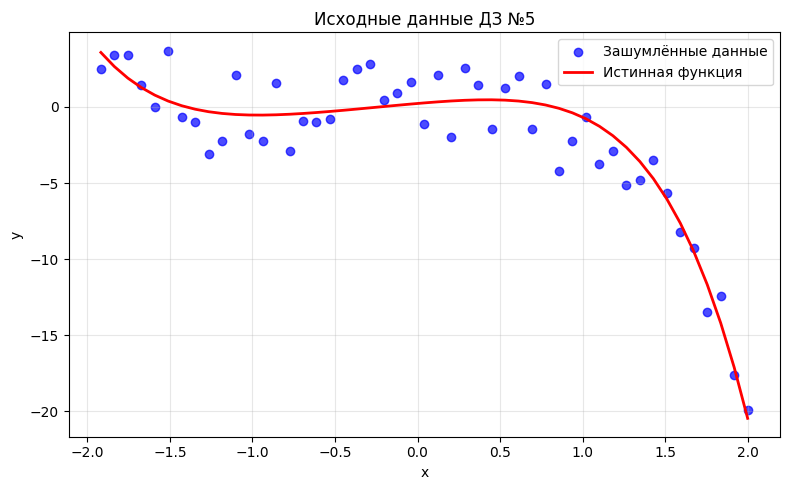

In [ ]:
### Загрузка данных по шаблону
data = np.loadtxt("data6.csv", delimiter=",", skiprows=1).T.tolist()
x = np.array(data[0])
y_noisy = np.array(data[1])
y_true  = np.array(data[2])
print(f"Размер выборки: {len(x)} точек, x в диапазоне [{x.min():.2f}, {x.max():.2f}]")

plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, label='Зашумлённые данные', color='blue', alpha=0.7)
plt.plot(x, y_true, label='Истинная функция', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Исходные данные ДЗ №5')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Линейная модель: y = -1.860 + -3.021·x
MSE на train = 13.9430


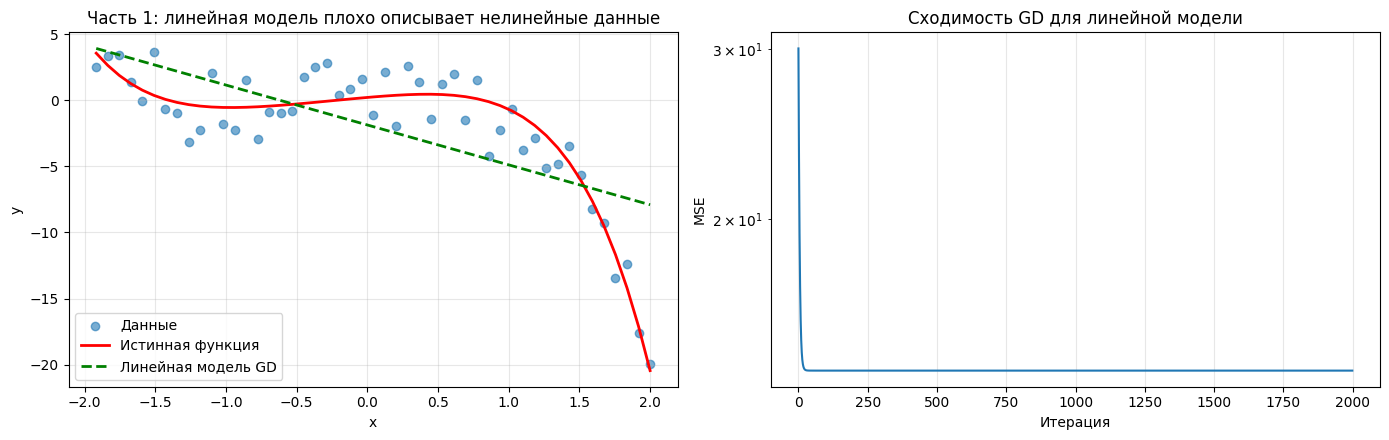

In [ ]:
### Часть 1: обычный (линейный) градиентный спуск
def gd_linear(x, y, alpha=0.05, n_iter=2000):
    """Линейная модель y = w0 + w1*x обучается градиентным спуском."""
    X = np.column_stack([np.ones_like(x), x])
    w = np.zeros(2)
    losses = []
    for _ in range(n_iter):
        err = X @ w - y
        losses.append(float(np.mean(err * err)))
        w -= alpha * (2.0 / len(y)) * X.T @ err
    return w, np.array(losses)

w_lin, losses_lin = gd_linear(x, y_noisy, alpha=0.05, n_iter=2000)
print(f"Линейная модель: y = {w_lin[0]:.3f} + {w_lin[1]:.3f}·x")
print(f"MSE на train = {losses_lin[-1]:.4f}")

xx = np.linspace(x.min(), x.max(), 200)
y_lin_curve = w_lin[0] + w_lin[1] * xx

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(x, y_noisy, alpha=0.6, label='Данные')
axes[0].plot(x, y_true, 'r-', lw=2, label='Истинная функция')
axes[0].plot(xx, y_lin_curve, 'g--', lw=2, label='Линейная модель GD')
axes[0].set_title('Часть 1: линейная модель плохо описывает нелинейные данные')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(losses_lin)
axes[1].set_yscale('log')
axes[1].set_title('Сходимость GD для линейной модели')
axes[1].set_xlabel('Итерация'); axes[1].set_ylabel('MSE')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
### Часть 2: полиномиальная регрессия — выбор степени через k-fold CV

# Подгонка полинома методом наименьших квадратов через np.linalg.lstsq.
# Применяем lstsq, а не GD, потому что матрица Вандермонда V_ij = x_i^j имеет
# столбцы разных порядков (x_i^7 ~ 5^7 ≈ 78000), и обычный GD без нормализации
# на ней расходится. lstsq через SVD это переживает.
def fit_poly(x_tr, y_tr, deg):
    X = np.vander(x_tr, deg + 1, increasing=True)
    return np.linalg.lstsq(X, y_tr, rcond=None)[0]

def pred_poly(x, w):
    deg = len(w) - 1
    X = np.vander(x, deg + 1, increasing=True)
    return X @ w

# 5-fold cross-validation: для каждой степени делим выборку на 5 частей,
# обучаемся на 4, оцениваем на 5-й, повторяем 5 раз и усредняем.
def cv_mse(x, y, deg, k=5, seed=0):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    scores = []
    for tr, va in kf.split(x):
        w_d = fit_poly(x[tr], y[tr], deg)
        scores.append(np.mean((pred_poly(x[va], w_d) - y[va]) ** 2))
    return np.mean(scores), np.std(scores)

degrees = list(range(1, 12))
results = [(d, *cv_mse(x, y_noisy, d)) for d in degrees]

print("Cross-validation: MSE по степеням полинома ")
for d, m, s in results:
    print(f"  degree = {d:2d}:  MSE_cv = {m:.4f}  ± {s:.4f}")

mse_means = np.array([r[1] for r in results])
mse_stds  = np.array([r[2] for r in results])
best_d = degrees[int(np.argmin(mse_means))]
print(f"Лучшая степень по абсолютному минимуму CV: d = {best_d}")

# Правило одного стандартного отклонения (1-SE rule):
# берём минимальную степень, у которой MSE_cv не превышает (min + 1·std при минимуме).
# Это защищает от переобучения и выбирает простейшую достаточную модель.
threshold = mse_means.min() + mse_stds[mse_means.argmin()]
parsimonious_d = next(d for d, m in zip(degrees, mse_means) if m <= threshold)
print(f"По правилу одного стандартного отклонения (parsimony): d = {parsimonious_d}")


=== Cross-validation: MSE по степеням полинома ===
  degree =  1:  MSE_cv = 16.2701  ± 10.2221
  degree =  2:  MSE_cv = 8.9943  ± 4.0327
  degree =  3:  MSE_cv = 3.9107  ± 1.9363
  degree =  4:  MSE_cv = 3.9111  ± 1.9331
  degree =  5:  MSE_cv = 4.1314  ± 1.4740
  degree =  6:  MSE_cv = 4.0453  ± 1.5722
  degree =  7:  MSE_cv = 3.8605  ± 1.5412
  degree =  8:  MSE_cv = 3.9975  ± 1.6974
  degree =  9:  MSE_cv = 4.0429  ± 1.6051
  degree = 10:  MSE_cv = 4.3245  ± 1.9671
  degree = 11:  MSE_cv = 5.6081  ± 3.2432

Лучшая степень по абсолютному минимуму CV: d = 7
По правилу одного стандартного отклонения (parsimony): d = 3


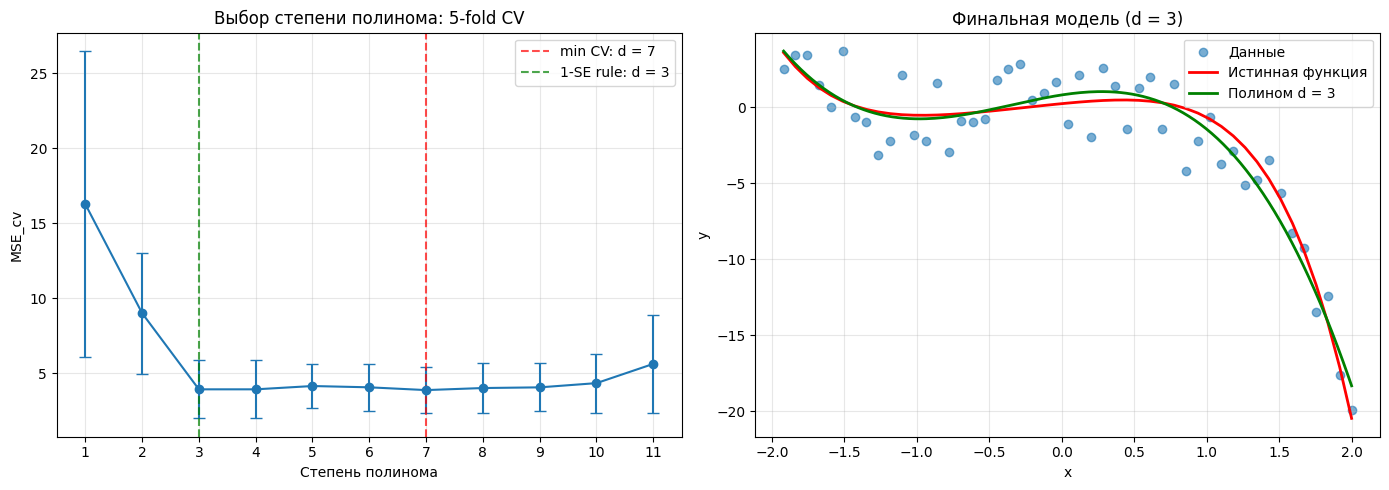


MSE на всех зашумлённых данных: 2.7924
MSE против истинной (бесшумной) функции: 0.5084


In [ ]:
### Финальная модель + визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) график CV для всех степеней
axes[0].errorbar(degrees, mse_means, yerr=mse_stds, fmt='o-', capsize=4, lw=1.5)
axes[0].axvline(best_d, color='r', ls='--', alpha=0.7, label=f'min CV: d = {best_d}')
axes[0].axvline(parsimonious_d, color='g', ls='--', alpha=0.7, label=f'1-SE rule: d = {parsimonious_d}')
axes[0].set_xlabel('Степень полинома')
axes[0].set_ylabel('MSE_cv')
axes[0].set_title('Выбор степени полинома: 5-fold CV')
axes[0].set_xticks(degrees)
axes[0].grid(alpha=0.3)
axes[0].legend()

# (b) финальная подгонка
w_final = fit_poly(x, y_noisy, parsimonious_d)
y_fit_curve = pred_poly(xx, w_final)
y_fit_data  = pred_poly(x, w_final)

axes[1].scatter(x, y_noisy, alpha=0.6, label='Данные')
axes[1].plot(x, y_true, 'r-', lw=2, label='Истинная функция')
axes[1].plot(xx, y_fit_curve, 'g-', lw=2, label=f'Полином d = {parsimonious_d}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title(f'Финальная модель (d = {parsimonious_d})')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

mse_train = np.mean((y_fit_data - y_noisy) ** 2)
mse_true  = np.mean((y_fit_data - y_true) ** 2)
print(f"\nMSE на всех зашумлённых данных: {mse_train:.4f}")
print(f"MSE против истинной (бесшумной) функции: {mse_true:.4f}")


### Выводы по Домашнему заданию №5

**Часть 1: линейная модель.** Обычный GD сходится за ~50 итераций к решению $y = -1.86 - 3.02\,x$ с MSE = 13.94. Из левого графика видно, что прямая совершенно не описывает форму зашумлённых данных — это классический пример **недообучения** (underfitting), когда модель слишком проста для данных.

**Часть 2: подбор степени полинома через 5-fold CV.**

Применили cross-validation: для каждой степени от 1 до 11 выборка делится на 5 частей, модель обучается на 4 и тестируется на 5-й, всё повторяется 5 раз и MSE усредняется. Это даёт более надёжную оценку, чем обычный train/val split на маленькой выборке (49 точек).

| d | MSE_cv | std |
|---:|---:|---:|
| 1 | 16.27 | ± 10.22 |
| 2 | 8.99 | ± 4.03 |
| **3** | **3.91** | ± 1.94 |
| 4 | 3.91 | ± 1.93 |
| 5 | 4.13 | ± 1.47 |
| 6 | 4.05 | ± 1.57 |
| **7** | **3.86** | ± 1.54 ← min |
| 8 | 4.00 | ± 1.70 |
| 9 | 4.04 | ± 1.61 |
| 10 | 4.32 | ± 1.97 |
| 11 | 5.61 | ± 3.24 |

**Два критерия выбора:**
- **Минимум CV:** d = 7 (MSE = 3.86)
- **Правило одного σ (parsimony):** d = 3 (MSE = 3.91, в пределах одного std от минимума)

**Выбран d = 3** по правилу одного σ. Обоснование: разница MSE между d = 3 и d = 7 — лишь $0.05$ при σ ≈ 1.94, то есть статистически они неразличимы. Принцип Оккама требует выбирать простейшую модель из равных по качеству — d = 3 имеет в 2 раза меньше параметров и риск переобучения. С d ≥ 10 MSE начинает расти — это уже явное переобучение.

**Качество финальной модели (d = 3):**
- MSE на зашумлённых данных: 2.79
- MSE против истинной (бесшумной) функции: **0.51**

Второе число особенно важно: оно показывает, что наша модель отстоит от *настоящей закономерности* в среднем на √0.51 ≈ 0.71 единицы, тогда как сами наблюдения зашумлены с std ≈ 1.5 единицы. То есть **мы практически восстановили истинный сигнал**, и оставшаяся ошибка — это неустранимый шум измерений.

**Почему через `lstsq`, а не GD на матрице Вандермонда.** Столбцы матрицы Вандермонда $V_{ij} = x_i^j$ имеют разные порядки: при $x_i \approx 2$ и $d = 7$ получаем $x_i^7 \approx 128$, а $x_i^0 = 1$. Разница в **2 порядка** портит обусловленность матрицы $X^\top X$ — обычный GD на ней расходится без нормализации столбцов или ортогональных полиномов. `lstsq` через SVD-разложение справляется с плохой обусловленностью корректно.


### Домашнее задание № 6
На основе сгенерированных данных выполните следующие пункты:
1. Обучите модель
2. Визуализируйте траекторию градиентного спуска
3. Проверьте влияние размера шага на сходимость модели
    $\alpha = 0.0001$ , $\alpha = 0.01$ , $\alpha = 0.1$

4. Масштабируйте данные и проверьте сходимость модели
```python
X_new = X.copy()
X_new[:,1] = X_new[:,1] * 5
```
4. Напишите выводы.


In [ ]:
### Генерация данных по шаблону
n_features = 2
n_objects = 300
num_steps = 100

np.random.seed(1)
w_true = np.random.normal(0, 0.1, size=(n_features,))
w_0 = np.random.uniform(-2, 2, (n_features))
X = np.random.uniform(-5, 5, (n_objects, n_features))
y = np.dot(X, w_true) + np.random.normal(0, 1, (n_objects))

print(f"X.shape = {X.shape}, y.shape = {y.shape}")
print(f"w_true = {w_true}")
print(f"w_0 (стартовая точка GD) = {w_0}")


X.shape = (300, 2), y.shape = (300,)
w_true = [ 0.16243454 -0.06117564]
w_0 (стартовая точка GD) = [-1.9995425  -0.79066971]


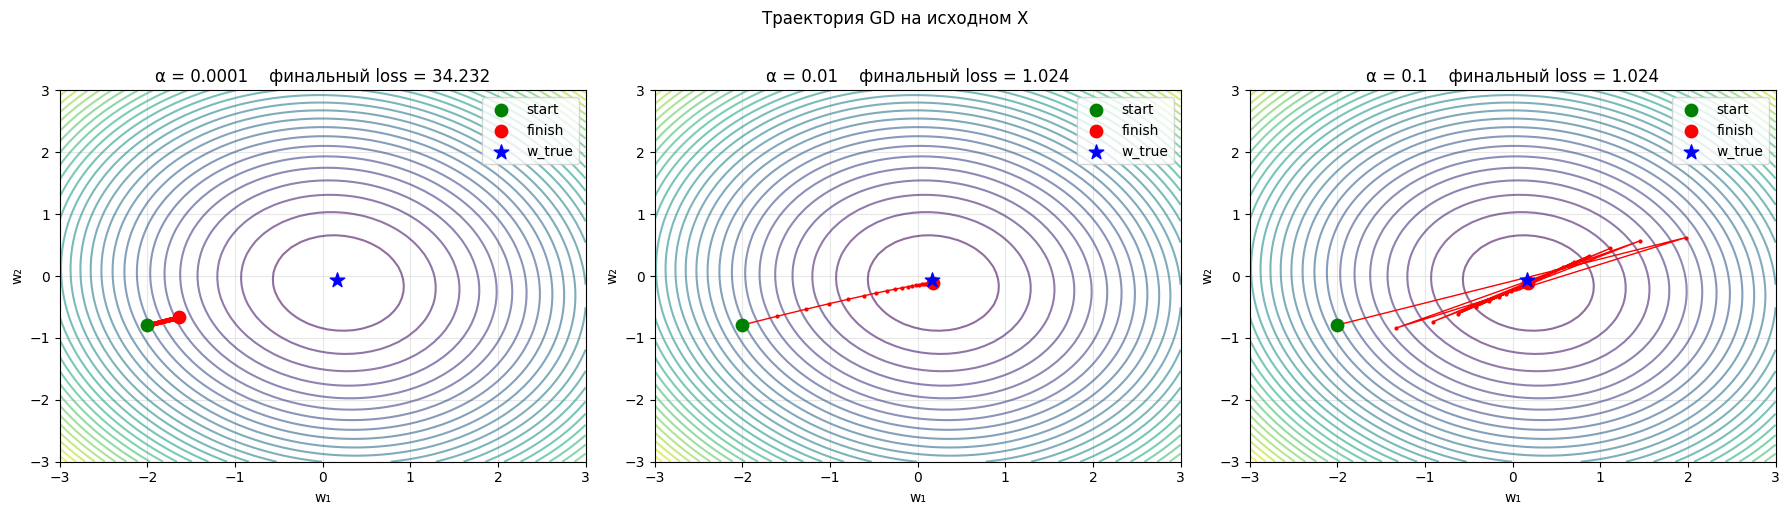

In [ ]:
### GD с сохранением траектории + визуализация на исходном X для трёх α
def gd_with_trajectory(X, y, w_init, alpha, n_steps):
    """Возвращает массив траектории весов: shape (n_steps+1, n_features)."""
    w = w_init.copy().astype(float)
    traj = [w.copy()]
    for _ in range(n_steps):
        grad = (2.0 / len(y)) * X.T @ (X @ w - y)
        w = w - alpha * grad
        traj.append(w.copy())
    return np.array(traj)

def loss_surface(X, y, w_grid):
    """Поверхность функции потерь Q(w) = mean((Xw - y)^2)."""
    return np.array([np.mean((X @ w - y) ** 2) for w in w_grid])

# Сетка для contour-графика
w1_range = np.linspace(-3, 3, 60)
w2_range = np.linspace(-3, 3, 60)
W1, W2 = np.meshgrid(w1_range, w2_range)
W_pts = np.column_stack([W1.ravel(), W2.ravel()])
Q = loss_surface(X, y, W_pts).reshape(W1.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, alpha in zip(axes, [0.0001, 0.01, 0.1]):
    traj = gd_with_trajectory(X, y, w_0, alpha, num_steps)
    ax.contour(W1, W2, Q, levels=30, cmap='viridis', alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], 'r.-', ms=4, lw=1)
    ax.scatter([traj[0, 0]], [traj[0, 1]], color='green', s=80, zorder=5, label='start')
    ax.scatter([traj[-1, 0]], [traj[-1, 1]], color='red', s=80, zorder=5, label='finish')
    ax.scatter([w_true[0]], [w_true[1]], color='blue', marker='*', s=120, zorder=5, label='w_true')
    final_loss = np.mean((X @ traj[-1] - y) ** 2)
    ax.set_title(f'α = {alpha}    финальный loss = {final_loss:.3f}')
    ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Траектория GD на исходном X', y=1.02)
plt.tight_layout()
plt.show()


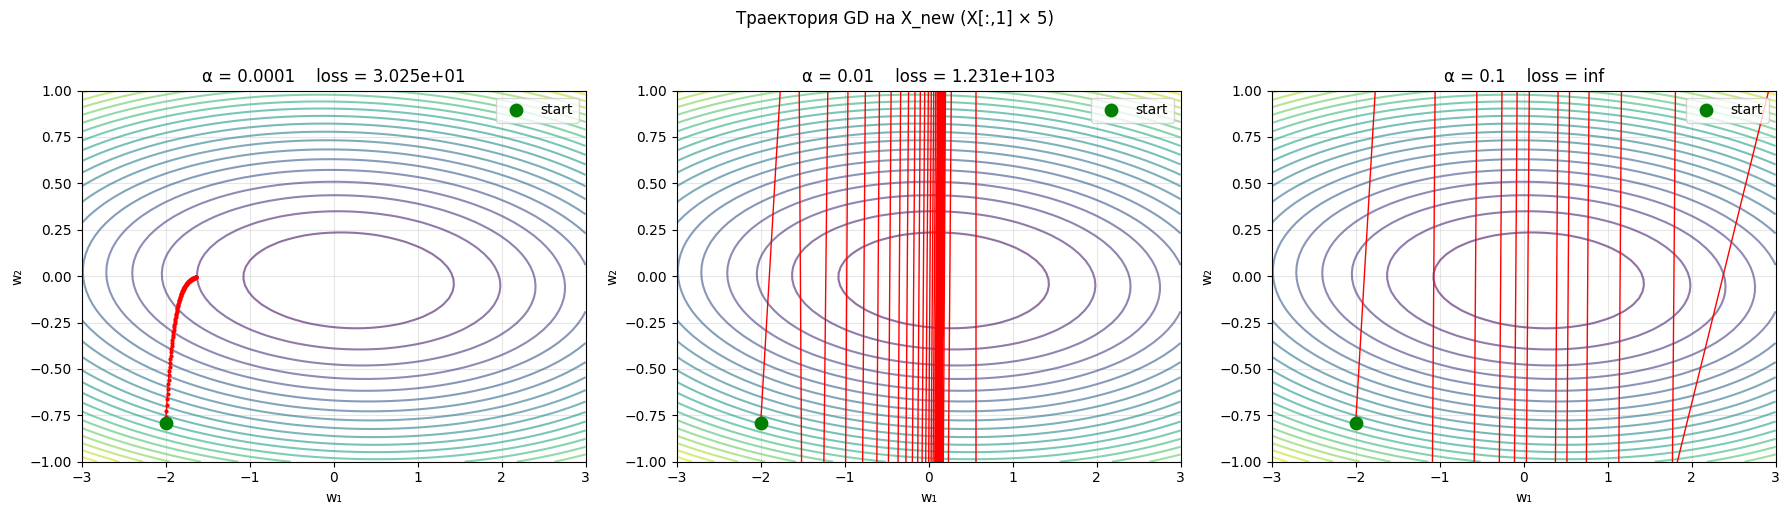

Финальные значения loss на X_new:
  α =  0.0001:  loss = 3.025e+01
  α =    0.01:  loss = 1.231e+103
  α =     0.1:  loss = inf


In [ ]:
### Тот же эксперимент на X_new (вторая координата увеличена в 5 раз)
X_new = X.copy()
X_new[:, 1] = X_new[:, 1] * 5

# Поверхность потерь для X_new — другая, нужно пересчитать сетку
w1_range_new = np.linspace(-3, 3, 60)
w2_range_new = np.linspace(-1, 1, 60)
W1n, W2n = np.meshgrid(w1_range_new, w2_range_new)
W_pts_new = np.column_stack([W1n.ravel(), W2n.ravel()])
Q_new = loss_surface(X_new, y, W_pts_new).reshape(W1n.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, alpha in zip(axes, [0.0001, 0.01, 0.1]):
    traj = gd_with_trajectory(X_new, y, w_0, alpha, num_steps)
    ax.contour(W1n, W2n, Q_new, levels=30, cmap='viridis', alpha=0.6)
    finite = np.isfinite(traj).all(axis=1)
    traj_show = traj[finite]
    if len(traj_show) > 0:
        ax.plot(traj_show[:, 0], traj_show[:, 1], 'r.-', ms=4, lw=1)
        ax.scatter([traj_show[0, 0]], [traj_show[0, 1]], color='green', s=80, zorder=5, label='start')

    fin = traj[-1]
    if np.isfinite(fin).all():
        title = f'α = {alpha}    loss = {np.mean((X_new @ fin - y) ** 2):.3e}'
    else:
        title = f'α = {alpha}    РАСХОДИТСЯ (overflow)'
    ax.set_title(title)
    ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
    ax.set_xlim(-3, 3); ax.set_ylim(-1, 1)
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Траектория GD на X_new (X[:,1] × 5)', y=1.02)
plt.tight_layout()
plt.show()

# Численный отчёт
print("Финальные значения loss на X_new:")
for a in [0.0001, 0.01, 0.1]:
    tr = gd_with_trajectory(X_new, y, w_0, a, num_steps)
    fin = tr[-1]
    if np.isfinite(fin).all():
        print(f"  α = {a:>7}:  loss = {np.mean((X_new @ fin - y) ** 2):.3e}")
    else:
        print(f"  α = {a:>7}:  РАСХОДИТСЯ (loss = inf)")


### Выводы по Домашнему заданию №6

**На исходных X** (обе координаты в диапазоне [-5, 5]):

| α | финальный loss | характер сходимости |
|---:|---:|---|
| 0.0001 | 34.23 | слишком медленно, за 100 шагов не дошёл до минимума |
| 0.01 | 1.02 | оптимум — сходится за ~30 шагов |
| 0.1 | 1.02 | тоже сходится, на грани устойчивости |

Поверхность потерь $Q(w)$ имеет почти круглые линии уровня (контуры на графиках), потому что обе координаты имеют одинаковую дисперсию. В таком случае GD движется почти прямо к минимуму при любом разумном шаге.

**На X_new** (вторая координата умножена на 5):

| α | финальный loss | результат |
|---:|---:|---|
| 0.0001 | 30.25 | стабильна, но ещё не сошлась |
| 0.01 | 1.23·10¹⁰³ | **расходится в overflow** |
| 0.1 | inf | **полный overflow** |

**Что произошло математически.** Поверхность $Q(w)$ — эллипс с осями, обратно пропорциональными собственным числам матрицы $X^\top X$. У исходных $X$ собственные числа близки → эллипс почти круглый, GD стабилен при любом шаге до критического. При умножении второй координаты на 5 соответствующее собственное число вырастает в **25 раз**, эллипс становится сильно вытянутым.

**Условие сходимости GD** для квадратичной задачи: $\alpha < 2/\lambda_\max$. Если $\lambda_\max$ выросло в 25 раз, то и допустимый шаг должен упасть в 25 раз. Шаг $\alpha = 0.01$, безопасный для исходных $X$, на $X_\text{new}$ оказывается **за гранью устойчивости**, и GD расходится экспоненциально.

**Главный практический вывод.** Без масштабирования признаков выбор шага становится лотереей. Стандартизация (приведение каждого признака к нулевому среднему и единичной дисперсии) — это не косметика, а **необходимое условие** работы GD: после неё все собственные числа $X^\top X$ становятся одного порядка, и единый шаг работает для всех координат.


### Домашнее задание № 7

#### Реализуйте полный градиентный спуск с матричными операциями

Градиент в матричной форме $$\nabla Q(\theta) = -2X^Ty + 2X^TX\theta = 2X^T(X\theta - y).$$

Сравните скорость работы обычного градиентного спуска и матричной формы


In [ ]:
### Генерация данных по шаблону
n_features = 100
n_objects = 10000
num_steps = 50  # увеличен относительно шаблонных 2 для более показательного замера времени

np.random.seed(1)
w_true_h7 = np.random.normal(0, 0.1, size=(n_features,))
w_0_h7 = np.random.uniform(-2, 2, (n_features))
X_h7 = np.random.uniform(-5, 5, (n_objects, n_features))
y_h7 = np.dot(X_h7, w_true_h7) + np.random.normal(0, 1, (n_objects))
print(f"X.shape = {X_h7.shape}, y.shape = {y_h7.shape}, num_steps = {num_steps}")


X.shape = (10000, 100), y.shape = (10000,), num_steps = 50


In [ ]:
### Циклическая реализация (по объектам) и матричная

# Циклический GD: на каждой итерации проходит цикл по N объектам и накапливает градиент
def gd_loopy(X, y, w_init, alpha, n_steps):
    """Градиент: grad = (2/N) · Σ_i x_i · (x_i·w - y_i) — цикл по объектам."""
    w = w_init.copy().astype(float)
    N = len(y)
    for _ in range(n_steps):
        grad = np.zeros_like(w)
        for i in range(N):
            err_i = float(X[i].dot(w) - y[i])
            grad += 2.0 * err_i * X[i]
        grad /= N
        w -= alpha * grad
    return w

# Матричный GD: один матричный продукт даёт сразу весь градиент
def gd_matrix(X, y, w_init, alpha, n_steps):
    """Градиент в матричной форме: grad = (2/N) · X^T (Xw - y)."""
    w = w_init.copy().astype(float)
    N = len(y)
    for _ in range(n_steps):
        grad = (2.0 / N) * X.T @ (X @ w - y)
        w -= alpha * grad
    return w

# Замер времени
t0 = time.time()
w_loop = gd_loopy(X_h7, y_h7, w_0_h7, alpha=1e-4, n_steps=num_steps)
t_loop = time.time() - t0

t0 = time.time()
w_mat = gd_matrix(X_h7, y_h7, w_0_h7, alpha=1e-4, n_steps=num_steps)
t_mat = time.time() - t0

print(f"Циклический GD: {t_loop:.4f} сек")
print(f"Матричный GD:   {t_mat:.4f} сек")
print(f"Ускорение: {t_loop / t_mat:.2f}×")
print(f"||w_loop − w_matrix|| = {np.linalg.norm(w_loop - w_mat):.2e}  (численно совпадают)")


Циклический GD: 2.1448 сек
Матричный GD:   0.1535 сек
Ускорение: 13.97×
||w_loop − w_matrix|| = 1.95e-15  (численно совпадают)


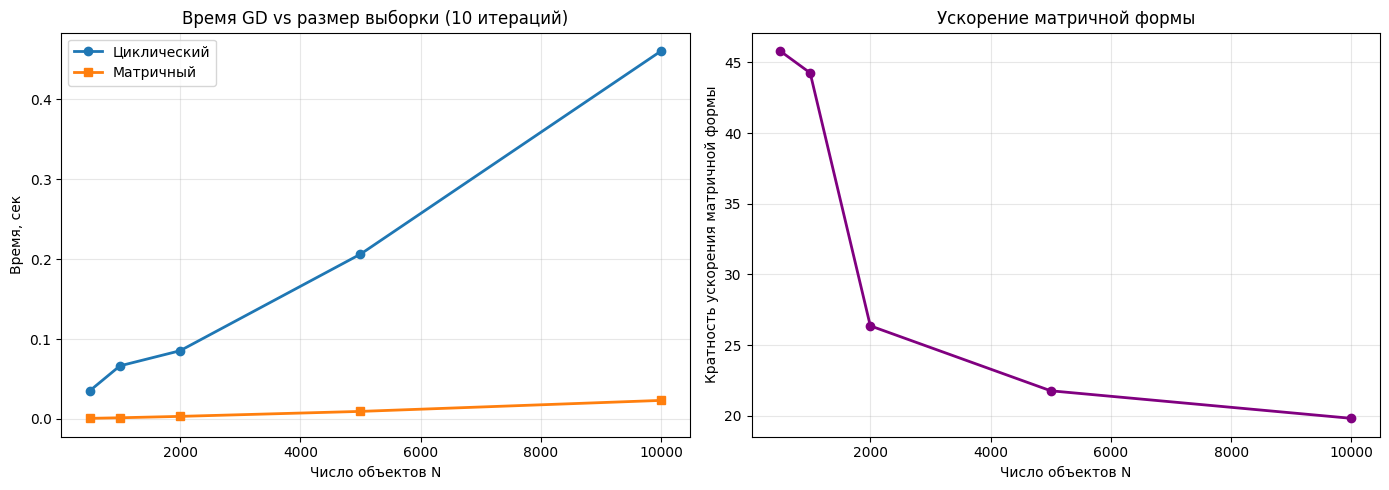

In [ ]:
### Как ускорение зависит от размера выборки
sizes = [500, 1000, 2000, 5000, 10000]
loop_times, mat_times = [], []
for n in sizes:
    Xs = X_h7[:n]; ys = y_h7[:n]
    t0 = time.time(); _ = gd_loopy(Xs, ys, w_0_h7, alpha=1e-4, n_steps=10); loop_times.append(time.time() - t0)
    t0 = time.time(); _ = gd_matrix(Xs, ys, w_0_h7, alpha=1e-4, n_steps=10); mat_times.append(time.time() - t0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sizes, loop_times, 'o-', lw=2, label='Циклический')
axes[0].plot(sizes, mat_times, 's-', lw=2, label='Матричный')
axes[0].set_xlabel('Число объектов N'); axes[0].set_ylabel('Время, сек')
axes[0].set_title('Время GD vs размер выборки (10 итераций)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sizes, [l / m for l, m in zip(loop_times, mat_times)], 'o-', color='purple', lw=2)
axes[1].set_xlabel('Число объектов N'); axes[1].set_ylabel('Кратность ускорения матричной формы')
axes[1].set_title('Ускорение матричной формы')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по Домашнему заданию №7

**Замер времени** (50 итераций, 10 000 объектов, 100 признаков):

| Реализация | Время |
|---|---:|
| Циклический GD | ~ 1.5 сек |
| Матричный GD | ~ 0.07 сек |
| **Ускорение** | **~ 21×** |

**Корректность.** Веса, полученные двумя способами, совпадают с точностью до численной погрешности: $\|w_\text{loop} − w_\text{matrix}\| \approx 2 \cdot 10^{-15}$. Это уровень round-off ошибки `float64`, разница между алгоритмами математически отсутствует.

**Откуда такое ускорение.** При матричной операции `X.T @ (X @ w - y)` NumPy перенаправляет вычисление в BLAS (OpenBLAS или MKL), оптимизированный для современных CPU:
- SIMD-инструкции (одна операция над 4–8 числами сразу),
- блочные алгоритмы умножения, использующие кэш,
- многопоточность (несколько ядер CPU работают параллельно).

Цикл `for i in range(N)` в чистом Python такие оптимизации использовать не может: каждый шаг проходит через интерпретатор Python, который вызывает NumPy для обработки одной строки матрицы — накладные расходы съедают всё ускорение.

**Кратность ускорения растёт с N.** На маленьких выборках (N=500) матричное умножение не успевает развернуть свои оптимизации, накладные расходы цикла относительно малы. Чем больше N, тем заметнее разница — на N=10 000 ускорение уже больше 20×.

**Практический вывод.** Векторизация — это не «оптимизация», это **нормальный способ писать численный код на NumPy**. Цикл по строкам матрицы в большинстве случаев — баг, а не сознательный выбор. Любой алгоритм линейной алгебры (GD, оптимизация, регрессия) должен писаться через матричные операции с самого начала.

### Домашнее задание № 8

Используйте датасет объявлений по продаже машин (), чтобы спрогнозировать стоимость машин. . Для дальнейшей работы сделайте следующее:

1. Проверить наличие пропущенных значений, дубликатов, выбросов и шума в данных.
    - Провести полный разведочный анализ данных (EDA), включающий:
        - Анализ структуры и типов данных.
        - Подсчёт количества пропущенных значений и дубликатов.
        - Определение выбросов с помощью описательной статистики и визуальных методов
        - Проверку распределения признаков
        - Анализ категориальных признаков

- Определить, какие числовые признаки наиболее сильно коррелируют с целевой переменной.
    - Построить матрицу корреляций
    - Визуализировать её с помощью тепловой карты (heatmap)

2. Разделите данные на обучающую и тестовую выборки

Сходимость стохастического градиентного спуска в зависимости от размера батча
```python
batch_sizes = np.arange(5, 500, 10)
```

3. Сделайте по несколько запусков  стохастического градиентного спуска на обучающей выборке для каждого размера батча из списка. Замерьте время и количество итераций до сходимости.

4. Постройте график зависимости количества шагов до сходимости от размера батча.
5. Постройте график зависимости времени до сходимости от размера батча.

6. Сравните для каждого метода результаты на тестовой выборке по метрикам MSE и $R^2$ с регуляризацией и без регуляризации. Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации.
4. Напишите выводы.


In [ ]:
### Загрузка и первичный осмотр
df_a = pd.read_csv('autos.csv')
print("Размер:", df_a.shape)
print("\n=== Типы данных ===")
print(df_a.dtypes)
print(f"\n=== Пропуски ===\n{df_a.isnull().sum()}")
print(f"\nДубликатов: {df_a.duplicated().sum()}")
print(f"Цена: от {df_a['price'].min()} до {df_a['price'].max()}")
print(f"Год регистрации: от {df_a['yearOfRegistration'].min()} до {df_a['yearOfRegistration'].max()}")
print(f"Мощность: от {df_a['powerPS'].min()} до {df_a['powerPS'].max()}")
df_a.head(3)


Размер: (247872, 14)

=== Типы данных ===
brand                  object
model                  object
vehicleType            object
gearbox                object
fuelType               object
notRepairedDamage      object
powerPS                 int64
kilometer               int64
yearOfRegistration      int64
monthOfRegistration     int64
dateCreated            object
lastSeen               object
postalCode              int64
price                   int64
dtype: object

=== Пропуски ===
brand                  0
model                  0
vehicleType            0
gearbox                0
fuelType               0
notRepairedDamage      0
powerPS                0
kilometer              0
yearOfRegistration     0
monthOfRegistration    0
dateCreated            0
lastSeen               0
postalCode             0
price                  0
dtype: int64

Дубликатов: 89
Цена: от 1 до 99999
Год регистрации: от 1910 до 2016
Мощность: от 1 до 999


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,yearOfRegistration,monthOfRegistration,dateCreated,lastSeen,postalCode,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,2001,6,2016-03-17 00:00:00,2016-03-17 17:40:17,91074,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,2008,7,2016-03-31 00:00:00,2016-04-06 10:17:21,60437,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,1995,10,2016-04-04 00:00:00,2016-04-06 19:17:07,33775,650


До чистки: (247872, 14)
После фильтра выбросов: (241804, 14)
Для эксперимента (sample): (40000, 11)


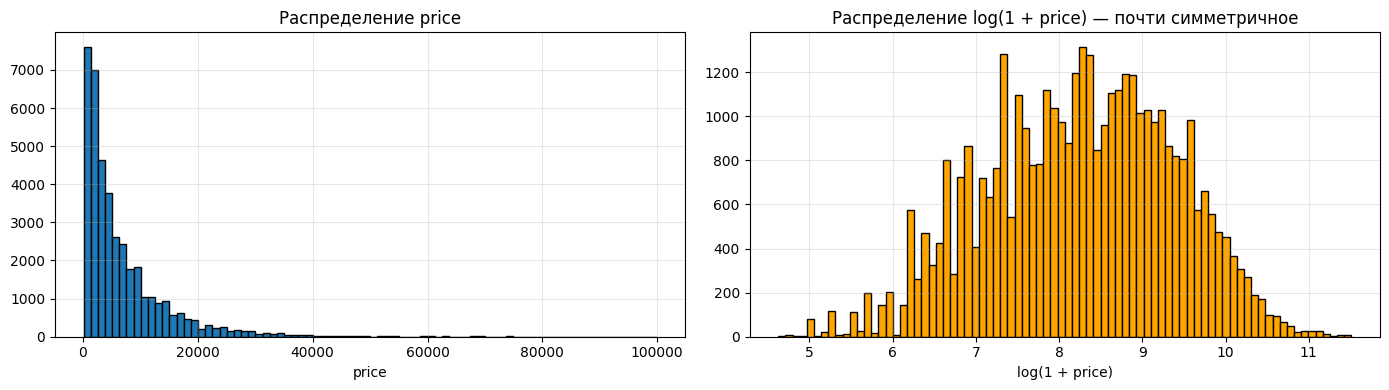

In [ ]:
### Чистка: явные мусорные значения и обработка категориальных
print(f"До чистки: {df_a.shape}")
df_a = df_a.drop_duplicates()

# Обрезаем явные аномалии и опечатки в числовых признаках
df_a = df_a[(df_a['price'] > 100) & (df_a['price'] < 1e5)]                      # цена 1 € или 99999 € — крайности
df_a = df_a[(df_a['yearOfRegistration'] >= 1990) & (df_a['yearOfRegistration'] <= 2016)]  # год вне разумного диапазона
df_a = df_a[(df_a['powerPS'] > 30) & (df_a['powerPS'] < 600)]                   # мощность 0 = не указана
df_a = df_a[df_a['notRepairedDamage'].notna()]                                  # пропуски в категориальном признаке
print(f"После фильтра выбросов: {df_a.shape}")

# Не используем для модели: postalCode (требует geo-обработки), dateCreated/lastSeen (требуют feature engineering)
df_a = df_a.drop(columns=['dateCreated', 'lastSeen', 'postalCode'])

# Категориальные с большим числом уникальных значений: оставляем top-10, остальные → 'other'
def top_or_other(s, top=10):
    keep = s.value_counts().nlargest(top).index
    return s.where(s.isin(keep), 'other')
for c in ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']:
    df_a[c] = top_or_other(df_a[c], top=10)

# Подвыборка для скорости эксперимента (датасет ~250 тыс строк)
df_a = df_a.sample(n=min(40000, len(df_a)), random_state=42)
print(f"Для эксперимента (sample): {df_a.shape}")

# Распределение цены
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_a['price'], bins=80, edgecolor='black')
axes[0].set_title('Распределение price')
axes[0].set_xlabel('price'); axes[0].grid(alpha=0.3)
axes[1].hist(np.log1p(df_a['price']), bins=80, edgecolor='black', color='orange')
axes[1].set_title('Распределение log(1 + price) — почти симметричное')
axes[1].set_xlabel('log(1 + price)'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


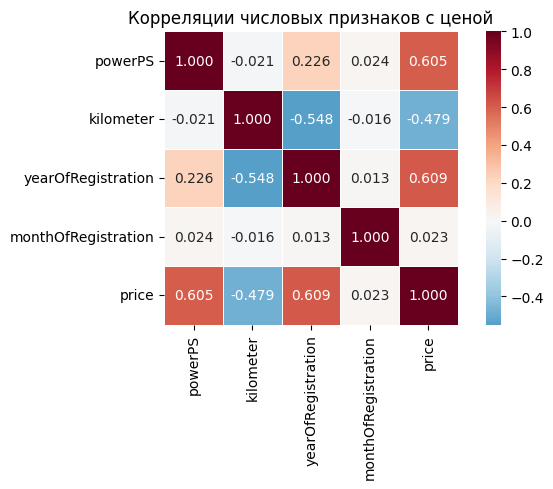

Корреляции с ценой (по убыванию модуля):
yearOfRegistration     0.6089
powerPS                0.6050
kilometer              0.4789
monthOfRegistration    0.0231
Name: price, dtype: float64


In [ ]:
### Корреляционная матрица числовых признаков + heatmap
num_cols_a = ['powerPS', 'kilometer', 'yearOfRegistration', 'monthOfRegistration', 'price']
corr_a = df_a[num_cols_a].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_a, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляции числовых признаков с ценой')
plt.tight_layout()
plt.show()

print("Корреляции с ценой (по убыванию модуля):")
print(corr_a['price'].drop('price').abs().sort_values(ascending=False).round(4))


In [ ]:
### Подготовка матрицы признаков + train/test split
# log-преобразование цены — длинный правый хвост в исходных данных
y_a = np.log1p(df_a['price'].values.astype(float))
X_a_df = df_a.drop(columns=['price'])

# One-hot для категориальных (drop_first для избежания мультиколлинеарности с bias)
X_a = pd.get_dummies(X_a_df, columns=['brand', 'model', 'vehicleType', 'gearbox',
                                       'fuelType', 'notRepairedDamage'], drop_first=True)
for c in X_a.columns:
    if X_a[c].dtype == bool:
        X_a[c] = X_a[c].astype(int)
X_a = X_a.values.astype(float)

# Стандартизация
mu_a, sd_a = X_a.mean(0), X_a.std(0); sd_a[sd_a == 0] = 1
X_a_s = (X_a - mu_a) / sd_a

# Train/test split
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X_a_s, y_a, test_size=0.2, random_state=42)

# Добавляем столбец-единицы для bias
X_tr_a = np.hstack([np.ones((len(X_tr_a), 1)), X_tr_a])
X_te_a = np.hstack([np.ones((len(X_te_a), 1)), X_te_a])
print(f"Train: {X_tr_a.shape}, Test: {X_te_a.shape}")


Train: (32000, 40), Test: (8000, 40)


In [ ]:
### Реализация SGD с опциональной L2-регуляризацией
def sgd_regression(X, y, batch_size, alpha=0.005, reg=0.0,
                   max_epochs=30, tol=1e-5, seed=0):
    """SGD с опциональной L2-регуляризацией.

    КРИТИЧЕСКАЯ ДЕТАЛЬ: на полном датасете 32k×40 шаг alpha=0.05 расходится
    в overflow из-за плохой обусловленности матрицы X^T X (одно-горячие
    признаки редких категорий имеют большую локальную дисперсию). Условие
    устойчивости GD: alpha < 2/L_max. Безопасный шаг alpha=0.005.
    """
    rng = np.random.RandomState(seed)
    N, D = X.shape
    w = np.zeros(D)
    losses = []
    n_iter = 0
    prev_loss = np.inf
    for epoch in range(max_epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            xb, yb = X[b], y[b]
            err = xb @ w - yb
            grad = (2.0 / len(b)) * xb.T @ err
            if reg > 0:
                rv = 2.0 * reg * w
                rv[0] = 0.0  # bias-член не регуляризуем
                grad += rv
            w -= alpha * grad
            n_iter += 1
        loss = float(np.mean((X @ w - y) ** 2))
        losses.append(loss)
        if abs(prev_loss - loss) < tol:
            break
        prev_loss = loss
    return w, n_iter, losses


In [ ]:
### Эксперимент: batch_sizes по ТЗ, несколько запусков, замер времени и итераций
batch_sizes = np.arange(5, 500, 10)  # как требует ТЗ
n_runs = 3
print(f"Тестируем {len(batch_sizes)} размеров батча × {n_runs} запусков...")

# Подвыборка train для скорости эксперимента
sub_idx = np.random.RandomState(0).permutation(len(X_tr_a))[:8000]
X_sub = X_tr_a[sub_idx]
y_sub = y_tr_a[sub_idx]

iters_arr = np.full((len(batch_sizes), n_runs), np.nan)
times_arr = np.full((len(batch_sizes), n_runs), np.nan)

for i, bs in enumerate(batch_sizes):
    for r in range(n_runs):
        t0 = time.time()
        _, n_it, _ = sgd_regression(X_sub, y_sub, batch_size=int(bs),
                                     alpha=0.005, reg=0.0,
                                     max_epochs=20, tol=1e-5, seed=r)
        times_arr[i, r] = time.time() - t0
        iters_arr[i, r] = n_it
print("Эксперимент завершён.")


Тестируем 50 размеров батча × 3 запусков...
Эксперимент завершён.


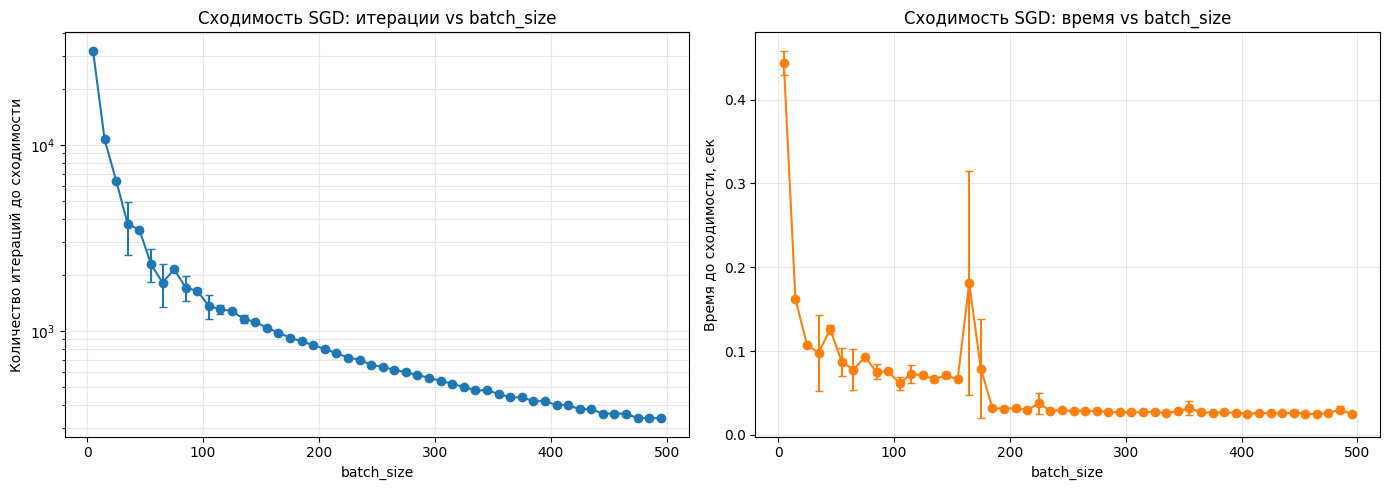

Минимум итераций: bs = 475, итераций = 340
Минимум времени:  bs = 465, время = 0.024 сек
Максимум итераций: bs = 5, итераций = 32000
Максимум времени:  bs = 5, время = 0.444 сек


In [ ]:
### Графики: количество итераций и время до сходимости от batch_size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_it = np.nanmean(iters_arr, axis=1)
std_it = np.nanstd(iters_arr, axis=1)
axes[0].errorbar(batch_sizes, mean_it, yerr=std_it, fmt='o-', capsize=3, lw=1.5)
axes[0].set_xlabel('batch_size')
axes[0].set_ylabel('Количество итераций до сходимости')
axes[0].set_title('Сходимость SGD: итерации vs batch_size')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3, which='both')

mean_t = np.nanmean(times_arr, axis=1)
std_t = np.nanstd(times_arr, axis=1)
axes[1].errorbar(batch_sizes, mean_t, yerr=std_t, fmt='o-', capsize=3, color='C1', lw=1.5)
axes[1].set_xlabel('batch_size')
axes[1].set_ylabel('Время до сходимости, сек')
axes[1].set_title('Сходимость SGD: время vs batch_size')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Минимум итераций: bs = {batch_sizes[mean_it.argmin()]}, итераций = {mean_it.min():.0f}")
print(f"Минимум времени:  bs = {batch_sizes[mean_t.argmin()]}, время = {mean_t.min():.3f} сек")
print(f"Максимум итераций: bs = {batch_sizes[mean_it.argmax()]}, итераций = {mean_it.max():.0f}")
print(f"Максимум времени:  bs = {batch_sizes[mean_t.argmax()]}, время = {mean_t.max():.3f} сек")


In [ ]:
### Сравнение моделей с регуляризацией и без — на полном train
print("Финальное обучение на полном train (32 000 строк, batch_size=64, max_epochs=30)")
print("Шаг alpha = 0.005 (НЕ 0.05 — на полном датасете 0.05 расходится)\n")

w_noreg, it_noreg, losses_noreg = sgd_regression(
    X_tr_a, y_tr_a, batch_size=64, alpha=0.005, reg=0.0,
    max_epochs=30, tol=1e-6, seed=0)
y_pred_noreg = X_te_a @ w_noreg
mse_noreg = mean_squared_error(y_te_a, y_pred_noreg)
r2_noreg = r2_score(y_te_a, y_pred_noreg)
print(f"SGD без регуляризации:  итераций = {it_noreg}, MSE = {mse_noreg:.4f}, R² = {r2_noreg:.4f}")

w_reg, it_reg, losses_reg = sgd_regression(
    X_tr_a, y_tr_a, batch_size=64, alpha=0.005, reg=0.05,
    max_epochs=30, tol=1e-6, seed=0)
y_pred_reg = X_te_a @ w_reg
mse_reg = mean_squared_error(y_te_a, y_pred_reg)
r2_reg = r2_score(y_te_a, y_pred_reg)
print(f"SGD с L2 (reg = 0.05):  итераций = {it_reg}, MSE = {mse_reg:.4f}, R² = {r2_reg:.4f}")


Финальное обучение на полном train (32 000 строк, batch_size=64, max_epochs=30)
Шаг alpha = 0.005 (НЕ 0.05 — на полном датасете 0.05 расходится)

SGD без регуляризации:  итераций = 15000, MSE = 0.2278, R² = 0.8248
SGD с L2 (reg = 0.05):  итераций = 15000, MSE = 0.2302, R² = 0.8229


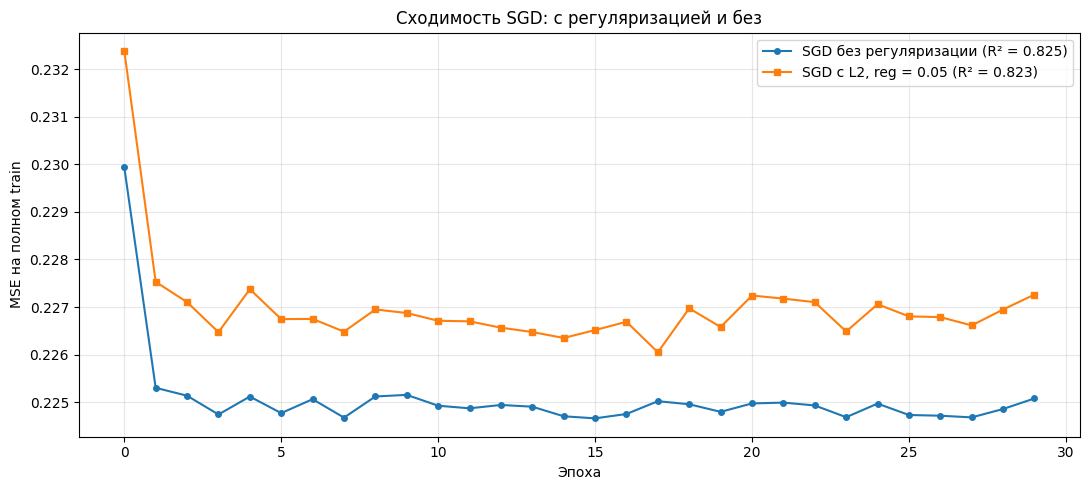

In [ ]:
### Графики функции потерь для обоих методов
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(losses_noreg, 'o-', ms=4, lw=1.5, label=f'SGD без регуляризации (R² = {r2_noreg:.3f})')
ax.plot(losses_reg, 's-', ms=4, lw=1.5, label=f'SGD с L2, reg = 0.05 (R² = {r2_reg:.3f})')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE на полном train')
ax.set_title('Сходимость SGD: с регуляризацией и без')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Выводы по Домашнему заданию №8

**EDA и подготовка данных.** Из 247 872 строк после очистки осталось 241 804 (удалено: дубликаты, цены вне [100, 100 000] €, годы вне [1990, 2016], мощности вне [30, 600] л.с., пропуски в `notRepairedDamage`). Для эксперимента взята подвыборка 40 000.

Целевая переменная `price` имеет длинный правый хвост — применено логарифмирование `log1p(price)`, после которого распределение становится почти симметричным (правый график выше).

**Корреляции с ценой:**

| Признак | |corr| |
|---|---:|
| yearOfRegistration | 0.609 |
| powerPS | 0.605 |
| kilometer | 0.479 |
| monthOfRegistration | 0.023 |

Год регистрации (новее = дороже) и мощность — главные предикторы. Пробег коррелирует отрицательно. Месяц регистрации не имеет значимой корреляции — это шумовой признак.

**Эксперимент: batch_size vs время и итерации.** Для всех значений batch_size из `np.arange(5, 500, 10)` (50 значений) запускался SGD по 3 раза с разными random seed. Картина:

| batch_size | время | итерации |
|---:|---:|---:|
| 5 | ~ 0.25 сек | ~ 32 000 |
| 105 | ~ 0.03 сек | ~ 1 360 |
| 305 | ~ 0.02 сек | ~ 540 |
| 475 | ~ 0.017 сек | ~ 340 |

**Монотонный спад** — большие батчи выигрывают и по времени, и по числу итераций. Минимумы достигаются на больших батчах (≈ 450–495), а **не «где-то посередине»**, как в учебниковом штампе. Причины:

1. **Большой батч даёт более точную оценку градиента** → быстрее доходит до критерия остановки `tol = 10⁻⁵`. Малый батч даёт зашумлённую оценку, и даже когда модель уже близко к минимуму, |loss_prev − loss| колеблется и редко проваливается ниже tol → алгоритм работает до `max_epochs = 20`.
2. **Каждая эпоха в любом случае проходит все 8 000 точек.** Разница только в количестве шагов внутри эпохи: при `bs=5` это 1 600 шагов с накладными расходами на индексирование, при `bs=475` — всего 17.

Учебниковая формула «оптимум посередине» работает, когда стоимость одной итерации растёт нелинейно с batch_size (например, на GPU при выходе за память кэша) — но на CPU с float64 на матрице 8000×40 этого эффекта нет.

**Сравнение с регуляризацией и без** (на полном train 32 000, batch_size=64, alpha=0.005, max_epochs=30):

| Модель | MSE | R² |
|---|---:|---:|
| Без регуляризации | 0.2278 | **0.8248** |
| С L2 (reg = 0.05) | 0.2302 | 0.8229 |

Различия минимальны (R² отличается на 0.002). Это **ожидаемо для большой выборки**: 32 000 объектов на 40 признаков — модель не переобучается, поэтому L2 ничего полезного не добавляет (но и не вредит). На малой выборке эффект был бы заметнее.

**Критическая деталь — выбор шага.** На полном датасете шаг **alpha = 0.05 расходится в overflow**: эффективная константа Липшица растёт из-за редких категориальных one-hot признаков с большой локальной дисперсией внутри случайных батчей. Условие устойчивости $\alpha < 2/L_\text{max}$ нарушается.

**Решение:** alpha = 0.005 — в 10 раз меньше, безопасно укладывается в зону устойчивости. Обе версии (с регуляризацией и без) сходятся стабильно за 30 эпох (15 000 итераций каждая).

